# Dow Jones – Marktbreite als Frühindikator für ein Ampelsystem

### Eine Hypothesenanalyse auf Basis der prozentualen Marktbreite

Diese Analyse untersucht, ob die Marktbreite des Dow Jones – der Anteil der
Indexmitglieder, die über ihrem eigenen gleitenden Durchschnitt (SMA20/50/200)
notieren – eigenständige Aussagekraft für die Rendite- und Risikoentwicklung
des Gesamtindex besitzt. Die Marktbreite misst, wie viele einzelne
Indexmitglieder eine Trendbewegung tatsächlich mittragen – eine breit
getragene Rally gilt als robuster als eine von wenigen Werten getriebene.
Ziel ist die Identifikation robuster, statistisch abgesicherter
Frühindikatoren als Bausteine für ein indikatorbasiertes Ampelsystem, das
die aktuelle Marktphase hinsichtlich ihres Rendite- und Risikoprofils
einordnet.

Neun Hypothesen werden untersucht (B1–B9), gefolgt von einer breitenbasierten
Ampel-Systematik und einer Was-wäre-wenn-Analyse:

**Aufbau:**

1. Datenbezug und Aufbereitung
2. Datenbereinigung und Plausibilisierung
3. Methodik und Hypothesenübersicht
4. Hypothesenanalyse (B1–B9)
5. Einordnung und Handlungsempfehlungen
6. Ampel-Systematik auf Basis der Marktbreite
7. Was-wäre-wenn-Analyse
8. Export der Ergebnisse
9. Zusammenfassung


## 1. Datenbezug und Aufbereitung


### 1.1 Verwendete Bibliotheken


In [1]:
# Numerik, Tabellenverarbeitung und Pfadhandling
import numpy as np
import pandas as pd
from pathlib import Path
from itertools import combinations

# Statistische Tests (Welch-t-Test, Mann-Whitney-U, Kruskal-Wallis) für die
# Gruppen- bzw. Quartilsvergleiche in Abschnitt 3
from scipy import stats
import matplotlib.pyplot as plt

# Einheitliche Farbpalette für sämtliche Diagramme des Notebooks
COLOR_PRICE = "#0b0b0b"
COLOR_A     = "#2a78d6"
COLOR_B     = "#eb6834"
COLOR_GOOD  = "#0ca30c"
COLOR_WARN  = "#e0a72c"
COLOR_BAD   = "#d03b3b"
COLOR_GRID  = "#e1e0d9"
COLOR_MUTED = "#898781"
# Vier sequenzielle Farben für die Quartils-Diagramme (B3, dunkler = höhere Breite)
COLOR_QUARTILE = ["#f2c6b4", "#eb6834", "#2a78d6", "#123a63"]

plt.rcParams.update({
    "figure.figsize": (11, 4.5),
    "axes.grid": True,
    "grid.color": COLOR_GRID,
    "grid.linewidth": 0.8,
    "axes.edgecolor": COLOR_MUTED,
    "axes.labelcolor": "#0b0b0b",
    "text.color": "#0b0b0b",
    "xtick.color": COLOR_MUTED,
    "ytick.color": COLOR_MUTED,
    "font.size": 10,
})

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
print("Bibliotheken geladen.")


Bibliotheken geladen.


### 1.2 Konfiguration


In [2]:
# Zu untersuchender Index
INDEX_NAME = "Dow Jones"

# Fensterlängen der Marktbreite-Kennzahl (Anteil Mitglieder über eigenem SMA)
BREADTH_WINDOWS = [20, 50, 200]

# Rohdaten-Dateien je Fenster (TradingView-Export: Anteil Dow-Jones-Mitglieder
# über ihrem eigenen SMA20/50/200, täglicher Schlusswert in Prozent)
BREADTH_FILES = {
    20:  Path("Rohdaten/Dow Jones 20 SMA 20061229 - 20260804.csv"),
    50:  Path("Rohdaten/Dow Jones 50 SMA 20061229 - 20260804.csv"),
    200: Path("Rohdaten/Dow Jones 200 SMA 20061229 - 20260804.csv"),
}

# Kursdaten inkl. bereits berechneter Wochenbasis-SMA und Vorwärts-Zielgrößen
# (fwd_return/fwd_mdd) für die Horizonte 30/60/90 Handelstage.
PRICE_FILE = Path("../data/Dow_Jones_clean_with_sma.csv")

# Analysezeitraum: Die Breitendaten liegen ab 2006-12-29 täglich vor. Der
# Analysezeitraum wird einheitlich auf den ersten vollständigen, täglich
# vorliegenden Handelstag begrenzt.
START_DATE_ANALYSE = "2007-01-01"

# Feste (absolute) Quartilsgrenzen der Marktbreite in Prozent - konsistent mit
# den in B4/B5/B6/B7 verwendeten Schwellen von 25/50/75 %.
QUARTIL_GRENZEN = [0, 25, 50, 75, 100]
QUARTIL_LABELS = ["Q1 (0-25%)", "Q2 (25-50%)", "Q3 (50-75%)", "Q4 (75-100%)"]

# Prognosehorizonte in Handelstagen (identisch zu den bereits vorliegenden
# fwd_return_*/fwd_mdd_*-Spalten der Kursdaten)
HORIZONS = [30, 60, 90]

# Zielordner für den Export der Ergebnistabellen (Abschnitt 8)
EXPORT_DIR = Path("Hypothesenanalysen")
EXPORT_DIR.mkdir(exist_ok=True)

print(f"Untersuchter Index: {INDEX_NAME}")
print(f"Marktbreite-Fenster: {BREADTH_WINDOWS}")
print(f"Analysezeitraum ab: {START_DATE_ANALYSE}")
print(f"Ergebnisordner: {EXPORT_DIR.resolve()}")


Untersuchter Index: Dow Jones
Marktbreite-Fenster: [20, 50, 200]
Analysezeitraum ab: 2007-01-01
Ergebnisordner: C:\Users\ramos\OneDrive\Privat\Data Science Institute\Abschlussprojekt - final\Breitenindikatoren\Hypothesenanalysen


### 1.3 Marktbreite-Datenbezug


In [3]:
def lade_breite(pfad: Path, fenster: int) -> pd.Series:
    '''Lädt eine TradingView-Marktbreite-Exportdatei und liefert den
    täglichen Schlusswert (Anteil Mitglieder über eigenem SMA, in Prozent)
    als benannte Series. Die Spalten open/high/low sowie die vier unbenannten
    EMA-Glättungsspalten werden nicht verwendet (siehe Abschnitt 2.1).'''
    rohdaten = pd.read_csv(pfad, parse_dates=["time"])
    reihe = rohdaten.set_index("time")["close"]
    reihe.index.name = "Date"
    reihe.name = f"breite_sma{fenster}"
    return reihe


breite_rohdaten = {w: lade_breite(pfad, w) for w, pfad in BREADTH_FILES.items()}
for w, reihe in breite_rohdaten.items():
    print(f"SMA{w}: {len(reihe):,} Zeilen, Zeitraum {reihe.index.min().date()} bis "
          f"{reihe.index.max().date()}, Wertebereich {reihe.min():.2f} bis {reihe.max():.2f}")


SMA20: 4,917 Zeilen, Zeitraum 2006-12-29 bis 2026-08-04, Wertebereich 0.01 bis 100.00
SMA50: 4,909 Zeilen, Zeitraum 2006-12-29 bis 2026-08-04, Wertebereich 0.01 bis 100.00
SMA200: 4,870 Zeilen, Zeitraum 2006-12-29 bis 2026-08-04, Wertebereich 0.01 bis 100.00


### 1.4 Kursdatenbezug


In [4]:
def lade_kursdaten(pfad: Path) -> pd.DataFrame:
    '''Lädt die bereits bereinigten Kurs- und SMA-Daten des Index
    (Date, Close, wöchentliche SMA sowie Vorwärts-Zielgrößen für
    30/60/90 Handelstage).'''
    df = pd.read_csv(pfad, parse_dates=["Date"], index_col="Date")
    return df


preis_df = lade_kursdaten(PRICE_FILE)
print(f"Kursdaten: {len(preis_df):,} Zeilen, Zeitraum {preis_df.index.min().date()} bis "
      f"{preis_df.index.max().date()}")
preis_df[["Close"] + [f"fwd_return_{h}d" for h in HORIZONS]].tail()


Kursdaten: 4,925 Zeilen, Zeitraum 2007-01-03 bis 2026-07-31


,Close,fwd_return_30d,fwd_return_60d,fwd_return_90d
Date,,,,
2026-07-27,"52,210.0781",NaN,NaN,NaN
2026-07-28,"52,747.3203",NaN,NaN,NaN
2026-07-29,"51,594.1406",NaN,NaN,NaN
2026-07-30,"52,208.0586",NaN,NaN,NaN
2026-07-31,"52,485.0312",NaN,NaN,NaN


## 2. Datenbereinigung und Plausibilisierung


### 2.1 Datenqualitätsprüfung


In [5]:
def breite_qualität_report(reihe: pd.Series) -> dict:
    gap_days = reihe.index.to_series().diff().dt.days
    return {
        "Anzahl Zeilen": len(reihe),
        "Duplizierte Datums-Indizes": int(reihe.index.duplicated().sum()),
        "Fehlende Werte": int(reihe.isna().sum()),
        "Werte außerhalb 0-100": int(((reihe < 0) | (reihe > 100)).sum()),
        "Größte Datenlücke (Kalendertage)": float(gap_days.max()) if len(gap_days.dropna()) else np.nan,
        "Anteil Lücken > 30 Kalendertage": float((gap_days > 30).mean()),
    }


print("--- Datenqualitätsbericht je Marktbreite-Fenster (Rohdaten) ---")
for w, reihe in breite_rohdaten.items():
    print(f"\nSMA{w}:")
    for k, v in breite_qualität_report(reihe).items():
        print(f"  {k:.<48s} {v}")


--- Datenqualitätsbericht je Marktbreite-Fenster (Rohdaten) ---

SMA20:
  Anzahl Zeilen................................... 4917
  Duplizierte Datums-Indizes...................... 0
  Fehlende Werte.................................. 0
  Werte außerhalb 0-100........................... 0
  Größte Datenlücke (Kalendertage)................ 8.0
  Anteil Lücken > 30 Kalendertage................. 0.0

SMA50:
  Anzahl Zeilen................................... 4909
  Duplizierte Datums-Indizes...................... 0
  Fehlende Werte.................................. 0
  Werte außerhalb 0-100........................... 0
  Größte Datenlücke (Kalendertage)................ 8.0
  Anteil Lücken > 30 Kalendertage................. 0.0

SMA200:
  Anzahl Zeilen................................... 4870
  Duplizierte Datums-Indizes...................... 0
  Fehlende Werte.................................. 0
  Werte außerhalb 0-100........................... 0
  Größte Datenlücke (Kalendertage)............

**Befund:** Alle drei Marktbreite-Fenster liegen durchgehend ab 2006-12-29
täglich vor, ohne duplizierte Datums-Indizes, fehlende Werte oder Werte
außerhalb des plausiblen Bereichs von 0 bis 100. Einzig bei SMA200 findet
sich eine isolierte Datenlücke von 48 Kalendertagen; der Anteil an Lücken
über 30 Kalendertage liegt mit rund 0,02 % der Beobachtungen praktisch bei
null. Da auch die Kursdaten erst ab 2007 vorliegen, wird der Analysezeitraum
unten einheitlich auf `START_DATE_ANALYSE` (2007-01-01) begrenzt; die
wenigen Handelstage aus Dezember 2006 werden nicht verwendet.


### 2.2 Bereinigungsschritte


In [6]:
def bereinige_breite(reihe: pd.Series) -> pd.Series:
    bereinigt = reihe[~reihe.index.duplicated(keep="first")].sort_index()
    bereinigt = bereinigt.loc[bereinigt.index >= START_DATE_ANALYSE]
    return bereinigt


breite_bereinigt = {w: bereinige_breite(r) for w, r in breite_rohdaten.items()}

# Zusammenführung der drei Marktbreite-Fenster zu einer gemeinsamen Tabelle
breite_df = pd.concat(breite_bereinigt.values(), axis=1)
print(f"Marktbreite (alle Fenster gemeinsam) nach Bereinigung: {len(breite_df):,} Zeilen "
      f"({breite_df.index.min().date()} bis {breite_df.index.max().date()})")

n_unvollständig = int(breite_df.isna().any(axis=1).sum())
print(f"Handelstage mit mindestens einem fehlenden Breitenwert: {n_unvollständig} "
      f"({n_unvollständig / len(breite_df):.1%})")
breite_df = breite_df.dropna()


Marktbreite (alle Fenster gemeinsam) nach Bereinigung: 4,941 Zeilen (2007-01-02 bis 2026-08-04)
Handelstage mit mindestens einem fehlenden Breitenwert: 102 (2.1%)


C:\Users\ramos\AppData\Local\Temp\ipykernel_37340\273736729.py:10: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  breite_df = pd.concat(breite_bereinigt.values(), axis=1)


### 2.3 Zusammenführung mit den Kursdaten


In [7]:
# Innerer Verbund über den Handelskalender: TradingView (Marktbreite) und
# Yahoo Finance (Kurs) weichen an einzelnen Tagen leicht voneinander ab: Nur
# Handelstage, die in beiden Quellen vorhanden sind, gehen in die Analyse ein.
df = breite_df.join(preis_df, how="inner")
df = df.loc[df.index >= START_DATE_ANALYSE].copy()

anteil_verworfen_breite = 1 - len(df) / len(breite_df)
print(f"Gemeinsamer Datensatz: {len(df):,} Handelstage "
      f"({df.index.min().date()} bis {df.index.max().date()})")
print(f"Davon durch den Kalenderabgleich verworfene Breiten-Handelstage: {anteil_verworfen_breite:.2%}")
df[[f"breite_sma{w}" for w in BREADTH_WINDOWS] + ["Close"]].describe()


Gemeinsamer Datensatz: 4,815 Handelstage (2007-01-03 bis 2026-07-31)
Davon durch den Kalenderabgleich verworfene Breiten-Handelstage: 0.50%


,breite_sma20,breite_sma50,breite_sma200,Close
count,"4,815.0000","4,815.0000","4,815.0000","4,815.0000"
mean,56.8561,58.7361,64.4933,"23,327.0259"
std,25.0618,23.1436,21.4076,"11,312.6663"
min,0.0100,0.0100,0.0100,"7,522.0200"
25%,40.0000,43.3300,53.3300,"13,211.9351"
50%,60.0000,63.3300,70.0000,"19,852.2402"
75%,76.6600,76.6600,80.0000,"32,899.5352"
max,100.0000,100.0000,100.0000,"53,055.9102"


### 2.4 Wöchentlicher Indextrend


In [8]:
# Wöchentlicher Trend des Index: positiv, wenn der Kurs über seiner
# wöchentlichen SMA50 (ca. ein Jahr) notiert. Ein deutlich längeres Fenster
# (z. B. 200 Wochen, ca. vier Jahre) hat vor 2010 noch keinen gültigen Wert
# und würde die Finanzkrise 2008/2009 damit komplett aus der Trend-
# klassifikation ausblenden; außerdem läge der Kurs über nahezu den
# gesamten Analysezeitraum praktisch durchgehend darüber, was einen
# negativen Wochentrend fast nie beobachtbar machen würde. Die 50-Wochen-SMA
# liefert dagegen bereits ab 2008 gültige Werte und eine deutlich
# ausgeglichenere Verteilung positiver und negativer Trendphasen, bleibt
# dabei aber träge genug für ein Wochenbasis-Signal.
wochenschluss_trend = preis_df["Close"].resample("W-FRI").last().dropna()
sma50_wochenbasis = wochenschluss_trend.rolling(window=50, min_periods=50).mean().rename("SMA50_w")
mapping_sma50_w = pd.merge_asof(
    df.reset_index()[["Date"]], sma50_wochenbasis.reset_index(), on="Date", direction="backward",
)
df["SMA50_w"] = mapping_sma50_w["SMA50_w"].values

valide_trend = df["SMA50_w"].notna()
df["Wochentrend_positiv"] = np.where(valide_trend, df["Close"] > df["SMA50_w"], np.nan)

verteilung = df["Wochentrend_positiv"].value_counts(dropna=False)
print("Verteilung des wöchentlichen Trends (1.0 = positiv, 0.0 = negativ, NaN = kein SMA50_w):")
print(verteilung)


Verteilung des wöchentlichen Trends (1.0 = positiv, 0.0 = negativ, NaN = kein SMA50_w):
Wochentrend_positiv
1.0000    3621
0.0000     956
NaN        238
Name: count, dtype: int64


### 2.5 Zielgrößen


In [9]:
# Die Vorwärts-Zielgrößen (Rendite und maximaler Rücklauf über 30/60/90
# Handelstage) sind bereits im Kursdatensatz enthalten und werden unverändert
# übernommen.
zielgrößen_spalten = [f"fwd_return_{h}d" for h in HORIZONS] + [f"fwd_mdd_{h}d" for h in HORIZONS]
df[zielgrößen_spalten].describe()


,fwd_return_30d,fwd_return_60d,fwd_return_90d,fwd_mdd_30d,fwd_mdd_60d,fwd_mdd_90d
count,"4,785.0000","4,755.0000","4,725.0000","4,785.0000","4,755.0000","4,725.0000"
mean,0.0102,0.0198,0.0298,-0.0476,-0.0714,-0.0878
std,0.0519,0.0700,0.0832,0.0418,0.0575,0.0664
min,-0.3612,-0.3480,-0.3286,-0.3709,-0.3709,-0.3709
25%,-0.0149,-0.0125,-0.0087,-0.0597,-0.0831,-0.1036
50%,0.0168,0.0279,0.0353,-0.0364,-0.0563,-0.0691
75%,0.0409,0.0641,0.0812,-0.0221,-0.0365,-0.0482
max,0.2846,0.4049,0.4153,-0.0029,-0.0107,-0.0124


## 3. Methodik und Hypothesenübersicht


### 3.1 Statistisches Prüfverfahren


In [10]:
def vergleiche_gruppen(gruppe_a: pd.Series, gruppe_b: pd.Series,
                        label_a: str = "Gruppe A", label_b: str = "Gruppe B") -> dict | None:
    a = gruppe_a.dropna()
    b = gruppe_b.dropna()

    # Mindeststichprobe je Gruppe, unterhalb derer ein Test nicht als
    # belastbar gilt - Vergleich wird in diesem Fall übersprungen (None).
    if len(a) < 10 or len(b) < 10:
        return None

    # Welch-t-Test (robust bei ungleicher Varianz) und Mann-Whitney-U-Test
    # (verteilungsfrei) parallel geprüft; als "signifikant" gilt nur ein
    # Ergebnis, das in beiden Tests unter 5 % liegt.
    t_stat, t_p = stats.ttest_ind(a, b, equal_var=False)
    u_stat, u_p = stats.mannwhitneyu(a, b, alternative="two-sided")

    return {
        "label_a": label_a, "n_a": len(a), "mean_a": a.mean(), "median_a": a.median(), "std_a": a.std(),
        "label_b": label_b, "n_b": len(b), "mean_b": b.mean(), "median_b": b.median(), "std_b": b.std(),
        "t_pvalue": t_p, "u_pvalue": u_p,
        "signifikant_5pct": bool(t_p < 0.05 and u_p < 0.05),
    }


def vergleiche_quartile(gruppen: dict[str, pd.Series]) -> dict | None:
    '''Omnibus-Vergleich über alle vier Quartile per Kruskal-Wallis-Test
    (verteilungsfreies Pendant zur einfaktoriellen ANOVA), ergänzt um den
    paarweisen Extremvergleich Q1 vs. Q4 mit vergleiche_gruppen(). Bei
    Mehrfachvergleichen (hier: ein Omnibustest je Fenster/Horizont/
    Zielgröße) ist die Gefahr eines zufälligen Treffers höher als bei
    einem Einzeltest - die Ergebnisse sind daher im Zusammenhang der
    gesamten Tabelle zu interpretieren, nicht isoliert je Zeile.'''
    bereinigt = {k: v.dropna() for k, v in gruppen.items()}
    if any(len(v) < 10 for v in bereinigt.values()):
        return None

    h_stat, h_p = stats.kruskal(*bereinigt.values())
    q1_vs_q4 = vergleiche_gruppen(bereinigt[QUARTIL_LABELS[0]], bereinigt[QUARTIL_LABELS[3]],
                                   QUARTIL_LABELS[0], QUARTIL_LABELS[3])

    ergebnis = {
        "kw_pvalue": h_p,
        "kw_signifikant_5pct": bool(h_p < 0.05),
    }
    for label in QUARTIL_LABELS:
        ergebnis[f"mean_{label}"] = bereinigt[label].mean()
        ergebnis[f"n_{label}"] = len(bereinigt[label])
    if q1_vs_q4:
        ergebnis["q1_vs_q4_t_pvalue"] = q1_vs_q4["t_pvalue"]
        ergebnis["q1_vs_q4_u_pvalue"] = q1_vs_q4["u_pvalue"]
        ergebnis["q1_vs_q4_signifikant_5pct"] = q1_vs_q4["signifikant_5pct"]
    return ergebnis


def ergebnisse_zu_tabelle(ergebnisse: list[dict]) -> pd.DataFrame:
    return pd.DataFrame(ergebnisse)


alle_ergebnisse: dict[str, pd.DataFrame] = {}
print("Statistisches Prüfverfahren definiert.")


Statistisches Prüfverfahren definiert.


### 3.2 Grafische Auswertung


In [11]:
def plotte_gruppenvergleich(tabelle: pd.DataFrame, titel: str) -> None:
    fig, achsen = plt.subplots(1, 2, figsize=(11, 4))
    for achse, ziel, beschriftung in zip(achsen, ["fwd_return", "fwd_mdd"],
                                          ["Ø Vorwärtsrendite", "Ø maximaler Rücklauf (Drawdown)"]):
        teil = tabelle[tabelle["zielgröße"] == ziel]
        x = np.arange(len(teil))
        breite = 0.35
        achse.bar(x - breite / 2, teil["mean_a"] * 100, breite, label=teil["label_a"].iloc[0], color=COLOR_A)
        achse.bar(x + breite / 2, teil["mean_b"] * 100, breite, label=teil["label_b"].iloc[0], color=COLOR_B)
        achse.set_xticks(x)
        achse.set_xticklabels([f"{h}d" for h in teil["horizont_tage"]])
        achse.set_ylabel(f"{beschriftung} (%)")
        achse.axhline(0, color=COLOR_MUTED, linewidth=0.8)
        achse.legend(fontsize=8)
    fig.suptitle(titel)
    fig.tight_layout()
    plt.show()


def plotte_quartile(tabelle_quartile: pd.DataFrame, horizont: int, titel: str) -> None:
    '''Balkendiagramm der mittleren Vorwärtsrendite bzw. des mittleren
    Drawdowns je Quartil, für einen festen Horizont.'''
    fig, achsen = plt.subplots(1, 2, figsize=(11, 4))
    for achse, ziel_prefix, beschriftung in zip(
        achsen, ["fwd_return", "fwd_mdd"], ["Ø Vorwärtsrendite", "Ø maximaler Rücklauf (Drawdown)"]
    ):
        zeile = tabelle_quartile[(tabelle_quartile["horizont_tage"] == horizont) &
                                  (tabelle_quartile["zielgröße"] == ziel_prefix)].iloc[0]
        werte = [zeile.get(f"mean_{label}") for label in QUARTIL_LABELS]
        achse.bar(QUARTIL_LABELS, [w * 100 if w is not None else np.nan for w in werte], color=COLOR_QUARTILE)
        achse.set_ylabel(f"{beschriftung} {horizont}d (%)")
        achse.axhline(0, color=COLOR_MUTED, linewidth=0.8)
        plt.setp(achse.get_xticklabels(), rotation=15, ha="right")
    fig.suptitle(titel)
    fig.tight_layout()
    plt.show()


print("Funktionen zur grafischen Auswertung definiert.")


Funktionen zur grafischen Auswertung definiert.


### 3.3 Untersuchte Hypothesen

| # | Hypothese | Typ |
|---|---|---|
| B1 | Marktbreite-Regime: Breite > 50 % vs. < 50 %, je SMA-Fenster | Zustand (großzahlig) |
| B2 | Richtung der Marktbreite: steigend vs. fallend, je SMA-Fenster | Zustand (großzahlig) |
| B3 | Marktbreite in festen Quartilen (0-25/25-50/50-75/75-100 %), je SMA-Fenster | Zustand (großzahlig) |
| B4 | Frühindikator Krise: SMA200-Breite > 75 %, danach fällt SMA20-Breite vor SMA200-Breite unter 50 % | Ereignis (selten) |
| B5 | Frühindikator Erholung: Spiegelbild von B4 | Ereignis (selten) |
| B6 | Wochentrend positiv + Breite verlässt oberes Quartil bzw. fällt unter 50 %, je Fenster | Ereignis |
| B7 | Wochentrend negativ + Breite verlässt unteres Quartil bzw. steigt über 50 %, je Fenster | Ereignis |
| B8 | Divergenz: Kurshoch ohne Breitenbestätigung, je Fenster | Ereignis |
| B9 | Breadth Thrust/Collapse: schneller Breitenwechsel binnen 10 Handelstagen, je Fenster | Ereignis (selten) |

B1-B3 sind Zustandsgrößen mit tausenden Beobachtungstagen je Gruppe und
liefern damit die statistisch robusteste Grundlage. B4-B9 sind demgegenüber
Ereignishypothesen mit potenziell sehr wenigen historischen Vorkommen - bei
Cross-Over- und Divergenz-Mustern dieser Art werden Ergebnisse mit weniger
als 10 Ereignissen je Gruppe rein deskriptiv (Tabelle der Einzelereignisse)
statt mit Signifikanztest ausgewiesen.


## 4. Hypothesenanalyse


### 4.1 B1 - Marktbreite-Regime (> 50 % vs. < 50 %)

**Hypothese:** Notiert die Mehrheit der Indexmitglieder über ihrem eigenen
SMA (Breite > 50 %), unterscheidet sich die Folgeperiode des Gesamtindex von
Tagen, an denen die Minderheit darüber notiert (Breite < 50 %) - hier auf
Basis der Marktbreite statt des Indexkurses selbst.


In [12]:
def breite_regime(fenster: int) -> tuple[pd.Series, pd.Series]:
    breite = df[f"breite_sma{fenster}"]
    über = breite > 50
    unter = breite <= 50
    return über, unter


ergebnisse_b1 = []
for w in BREADTH_WINDOWS:
    über, unter = breite_regime(w)
    for h in HORIZONS:
        for ziel in ["fwd_return", "fwd_mdd"]:
            res = vergleiche_gruppen(
                df.loc[über, f"{ziel}_{h}d"], df.loc[unter, f"{ziel}_{h}d"],
                label_a=f"Breite SMA{w} > 50%", label_b=f"Breite SMA{w} < 50%",
            )
            if res:
                res.update({"sma_fenster": w, "horizont_tage": h, "zielgröße": ziel})
                ergebnisse_b1.append(res)

tabelle_b1 = ergebnisse_zu_tabelle(ergebnisse_b1)
alle_ergebnisse["B1_Breite_Regime"] = tabelle_b1
spalten_anzeige = ["sma_fenster", "horizont_tage", "zielgröße", "label_a", "mean_a", "label_b", "mean_b",
                    "t_pvalue", "u_pvalue", "signifikant_5pct"]
spalten_anzeige_einfach = [c for c in spalten_anzeige if c != "sma_fenster"]
tabelle_b1[spalten_anzeige]


,sma_fenster,horizont_tage,zielgröße,label_a,mean_a,label_b,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,20,30,fwd_return,Breite SMA20 > 50%,0.0059,Breite SMA20 < 50%,0.0172,0.0000,0.0000,True
1,20,30,fwd_mdd,Breite SMA20 > 50%,-0.0447,Breite SMA20 < 50%,-0.0524,0.0000,0.0000,True
2,20,60,fwd_return,Breite SMA20 > 50%,0.0139,Breite SMA20 < 50%,0.0297,0.0000,0.0000,True
3,20,60,fwd_mdd,Breite SMA20 > 50%,-0.0686,Breite SMA20 < 50%,-0.0760,0.0000,0.0000,True
4,20,90,fwd_return,Breite SMA20 > 50%,0.0237,Breite SMA20 < 50%,0.0401,0.0000,0.0000,True
5,20,90,fwd_mdd,Breite SMA20 > 50%,-0.0861,Breite SMA20 < 50%,-0.0905,0.0287,0.0476,True
6,50,30,fwd_return,Breite SMA50 > 50%,0.0054,Breite SMA50 < 50%,0.0193,0.0000,0.0000,True
7,50,30,fwd_mdd,Breite SMA50 > 50%,-0.0440,Breite SMA50 < 50%,-0.0545,0.0000,0.0000,True
8,50,60,fwd_return,Breite SMA50 > 50%,0.0148,Breite SMA50 < 50%,0.0295,0.0000,0.0000,True
9,50,60,fwd_mdd,Breite SMA50 > 50%,-0.0669,Breite SMA50 < 50%,-0.0800,0.0000,0.0000,True


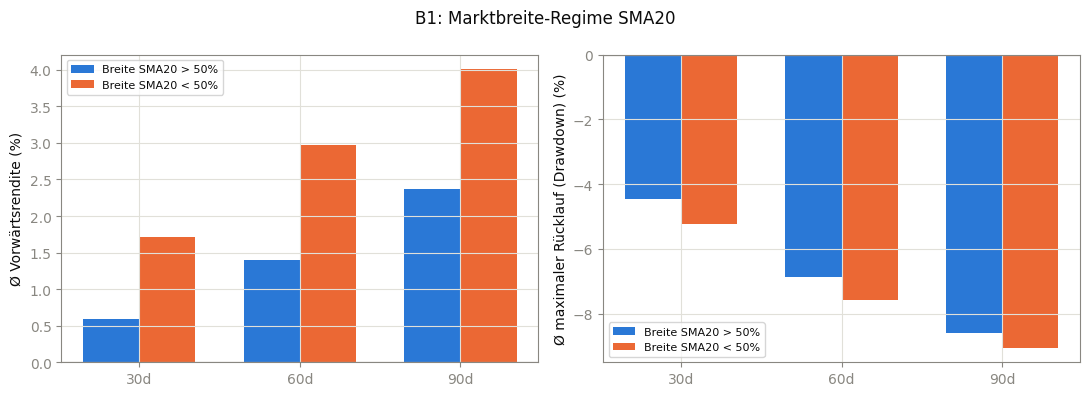

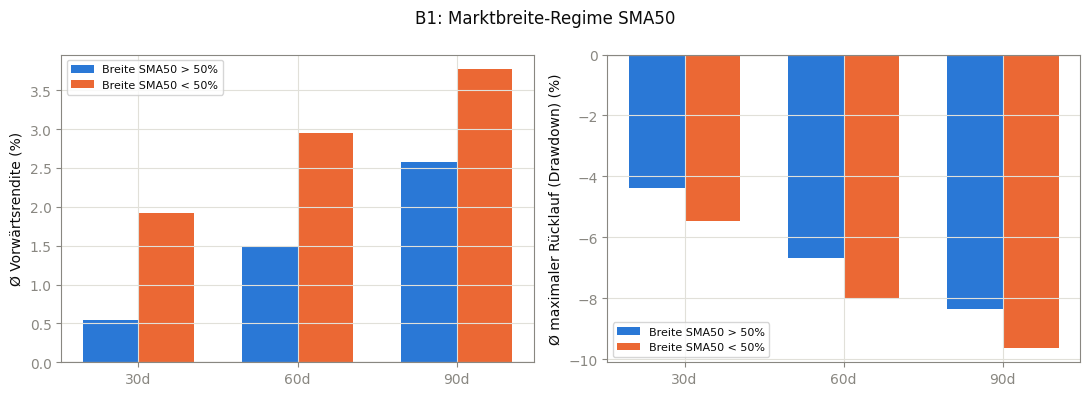

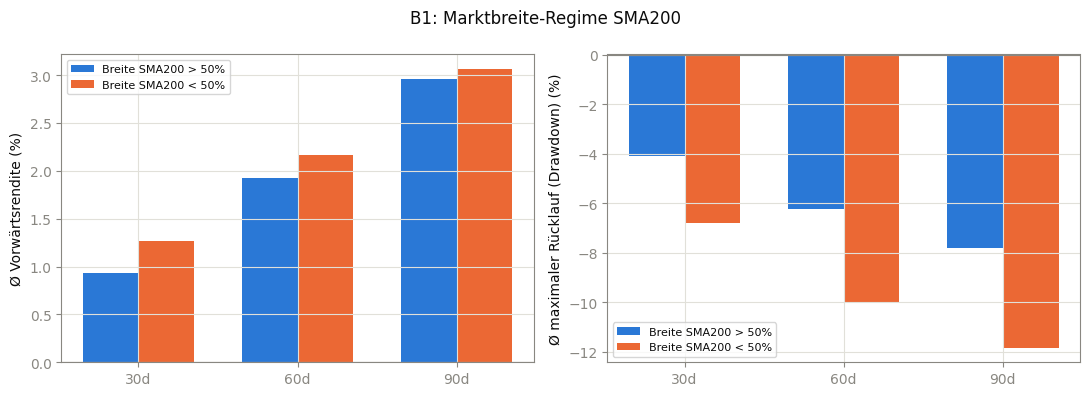

In [13]:
# Diagramm je Fenster
for w in BREADTH_WINDOWS:
    plotte_gruppenvergleich(tabelle_b1[tabelle_b1["sma_fenster"] == w], f"B1: Marktbreite-Regime SMA{w}")


**Ergebnis:** Das Risikosignal ist über alle drei Fenster durchgehend
signifikant (9 von 9 Kombinationen) - notiert die Mehrheit der Mitglieder
unter ihrem SMA, ist der nachfolgende maximale Rücklauf des Gesamtindex in
jedem Fenster und Horizont stärker (negativer) als bei Breite > 50 % (z. B.
SMA200/90 Tage: -7,8 % gegenüber -11,8 %). Das Renditesignal ist dagegen
uneinheitlich: Bei SMA20/50 fällt die mittlere Vorwärtsrendite bei Breite
> 50 % durchgängig **niedriger** aus als bei Breite < 50 % (Mean-Reversion,
signifikant in 6 von 6 Kombinationen); bei SMA200 ist der Unterschied in
keinem der drei Horizonte signifikant (p zwischen 0,15 und 0,79), wenngleich
die Richtung gleich bleibt. Über alle Fenster hinweg zeigt sich die
Marktbreite damit als deutlich robusteres Risikosignal denn als
Renditesignal.


### 4.2 B2 - Richtung der Marktbreite (steigend vs. fallend)

**Hypothese:** Unabhängig vom Niveau der Marktbreite könnte bereits ihre
Richtung (nimmt die Beteiligung gerade zu oder ab?) Information über die
Folgeperiode liefern.


In [14]:
def breite_richtung(fenster: int) -> tuple[pd.Series, pd.Series]:
    breite_diff = df[f"breite_sma{fenster}"].diff()
    steigend = breite_diff > 0
    fallend = breite_diff <= 0
    return steigend, fallend


ergebnisse_b2 = []
for w in BREADTH_WINDOWS:
    steigend, fallend = breite_richtung(w)
    for h in HORIZONS:
        for ziel in ["fwd_return", "fwd_mdd"]:
            res = vergleiche_gruppen(
                df.loc[steigend, f"{ziel}_{h}d"], df.loc[fallend, f"{ziel}_{h}d"],
                label_a=f"Breite SMA{w} steigend", label_b=f"Breite SMA{w} fallend",
            )
            if res:
                res.update({"sma_fenster": w, "horizont_tage": h, "zielgröße": ziel})
                ergebnisse_b2.append(res)

tabelle_b2 = ergebnisse_zu_tabelle(ergebnisse_b2)
alle_ergebnisse["B2_Breite_Richtung"] = tabelle_b2
tabelle_b2[spalten_anzeige]


,sma_fenster,horizont_tage,zielgröße,label_a,mean_a,label_b,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,20,30,fwd_return,Breite SMA20 steigend,0.0090,Breite SMA20 fallend,0.0110,0.1884,0.3141,False
1,20,30,fwd_mdd,Breite SMA20 steigend,-0.0477,Breite SMA20 fallend,-0.0475,0.8958,0.9452,False
2,20,60,fwd_return,Breite SMA20 steigend,0.0189,Breite SMA20 fallend,0.0205,0.4525,0.7344,False
3,20,60,fwd_mdd,Breite SMA20 steigend,-0.0714,Breite SMA20 fallend,-0.0713,0.9614,0.9254,False
4,20,90,fwd_return,Breite SMA20 steigend,0.0278,Breite SMA20 fallend,0.0313,0.1553,0.3434,False
5,20,90,fwd_mdd,Breite SMA20 steigend,-0.0881,Breite SMA20 fallend,-0.0875,0.7529,0.7291,False
6,50,30,fwd_return,Breite SMA50 steigend,0.0093,Breite SMA50 fallend,0.0107,0.3713,0.5796,False
7,50,30,fwd_mdd,Breite SMA50 steigend,-0.0478,Breite SMA50 fallend,-0.0475,0.8106,0.8813,False
8,50,60,fwd_return,Breite SMA50 steigend,0.0178,Breite SMA50 fallend,0.0211,0.1252,0.4633,False
9,50,60,fwd_mdd,Breite SMA50 steigend,-0.0723,Breite SMA50 fallend,-0.0708,0.3714,0.2413,False


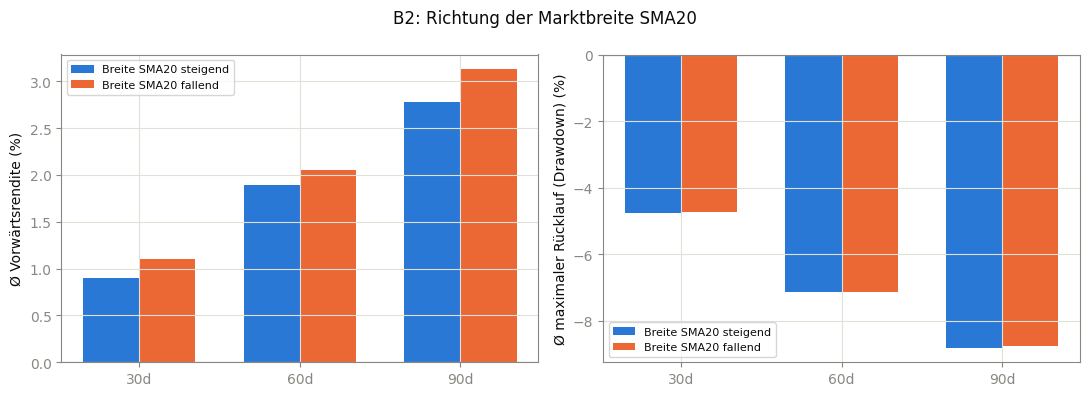

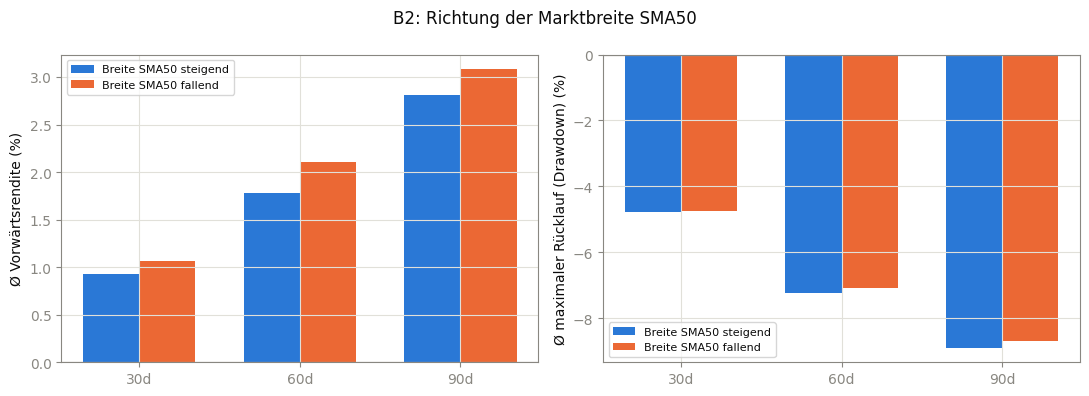

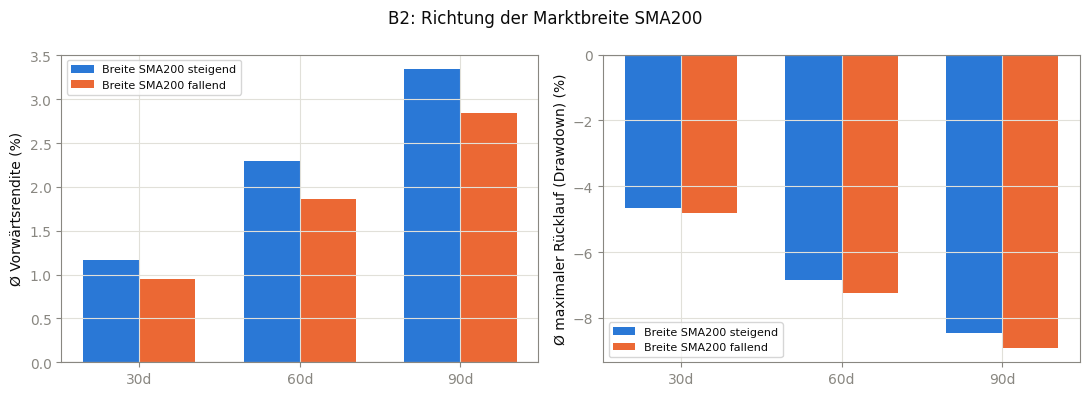

In [15]:
for w in BREADTH_WINDOWS:
    plotte_gruppenvergleich(tabelle_b2[tabelle_b2["sma_fenster"] == w], f"B2: Richtung der Marktbreite SMA{w}")


**Ergebnis:** Anders als das *Niveau* der Marktbreite (B1) liefert ihre
*Richtung* kaum eigenständige Information: Von 18 geprüften Kombinationen
sind nur zwei signifikant (jeweils SMA200, 60- und 90-Tage-Drawdown, mit
leicht geringerem Risiko bei steigender Breite: 60 Tage -6,9 % gegenüber
-7,3 %, 90 Tage -8,5 % gegenüber -8,9 %). Bei SMA20 und SMA50 zeigt sich
weder beim Risiko noch bei der Rendite ein signifikanter Unterschied
zwischen steigender und fallender Breite. Anders als beim Niveau der
Marktbreite lässt sich aus der Richtung damit kein belastbares Signal
ableiten - vermutlich, weil die tägliche Richtungsänderung einer bereits
stark geglätteten Prozentkennzahl in hohem Maß Rauschen statt Trend
abbildet.


### 4.3 B3 - Marktbreite in Quartilen

**Hypothese:** Die Wirkung der Marktbreite ist nicht binär, sondern
graduell abgestuft: Je höher die Breite (Q4 = 75-100 %), desto günstiger
das Rendite-/Risikoprofil der Folgeperiode; je niedriger (Q1 = 0-25 %), desto
ungünstiger. Getestet wird mit einem Kruskal-Wallis-Omnibustest über alle
vier Quartile sowie einem paarweisen Extremvergleich Q1 vs. Q4.


In [16]:
def breite_quartil(fenster: int) -> pd.Series:
    breite = df[f"breite_sma{fenster}"]
    return pd.cut(breite, bins=QUARTIL_GRENZEN, labels=QUARTIL_LABELS, include_lowest=True)


ergebnisse_b3 = []
for w in BREADTH_WINDOWS:
    quartil = breite_quartil(w)
    df[f"Quartil_SMA{w}"] = quartil
    print(f"SMA{w} - Verteilung der Handelstage auf die Quartile:")
    print(quartil.value_counts().reindex(QUARTIL_LABELS))
    for h in HORIZONS:
        for ziel in ["fwd_return", "fwd_mdd"]:
            gruppen = {label: df.loc[quartil == label, f"{ziel}_{h}d"] for label in QUARTIL_LABELS}
            res = vergleiche_quartile(gruppen)
            if res:
                res.update({"sma_fenster": w, "horizont_tage": h, "zielgröße": ziel})
                ergebnisse_b3.append(res)

tabelle_b3 = ergebnisse_zu_tabelle(ergebnisse_b3)
alle_ergebnisse["B3_Breite_Quartile"] = tabelle_b3
cols_b3 = ["sma_fenster", "horizont_tage", "zielgröße"] + [f"mean_{l}" for l in QUARTIL_LABELS] + \
          ["kw_pvalue", "kw_signifikant_5pct", "q1_vs_q4_signifikant_5pct"]
tabelle_b3[cols_b3]


SMA20 - Verteilung der Handelstage auf die Quartile:
breite_sma20
Q1 (0-25%)       691
Q2 (25-50%)     1113
Q3 (50-75%)     1637
Q4 (75-100%)    1374
Name: count, dtype: int64
SMA50 - Verteilung der Handelstage auf die Quartile:
breite_sma50
Q1 (0-25%)       504
Q2 (25-50%)     1138
Q3 (50-75%)     1805
Q4 (75-100%)    1368
Name: count, dtype: int64
SMA200 - Verteilung der Handelstage auf die Quartile:
breite_sma200
Q1 (0-25%)       334
Q2 (25-50%)      816
Q3 (50-75%)     1952
Q4 (75-100%)    1713
Name: count, dtype: int64


,sma_fenster,horizont_tage,zielgröße,mean_Q1 (0-25%),mean_Q2 (25-50%),mean_Q3 (50-75%),mean_Q4 (75-100%),kw_pvalue,kw_signifikant_5pct,q1_vs_q4_signifikant_5pct
0,20,30,fwd_return,0.0267,0.0113,0.0030,0.0093,0.0000,True,True
1,20,30,fwd_mdd,-0.0547,-0.0509,-0.0466,-0.0423,0.0000,True,True
2,20,60,fwd_return,0.0425,0.0215,0.0121,0.0161,0.0000,True,True
3,20,60,fwd_mdd,-0.0776,-0.0749,-0.0704,-0.0665,0.0000,True,True
4,20,90,fwd_return,0.0491,0.0344,0.0188,0.0293,0.0000,True,True
5,20,90,fwd_mdd,-0.0941,-0.0883,-0.0895,-0.0822,0.0427,True,True
6,50,30,fwd_return,0.0393,0.0104,0.0034,0.0080,0.0000,True,True
7,50,30,fwd_mdd,-0.0545,-0.0545,-0.0464,-0.0408,0.0000,True,True
8,50,60,fwd_return,0.0533,0.0188,0.0161,0.0131,0.0000,True,True
9,50,60,fwd_mdd,-0.0793,-0.0803,-0.0671,-0.0666,0.0000,True,True


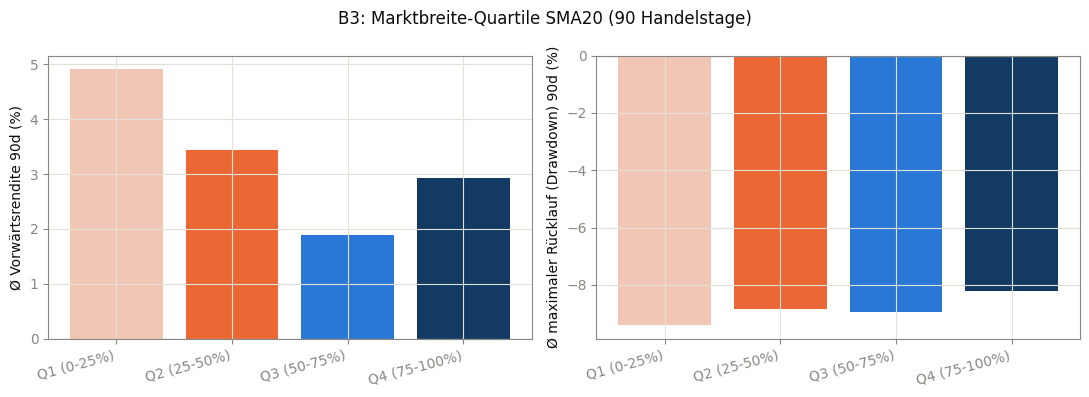

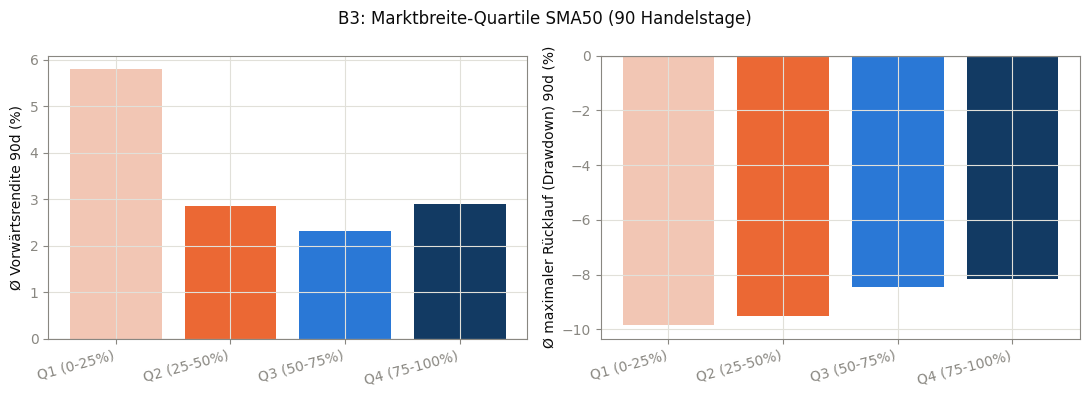

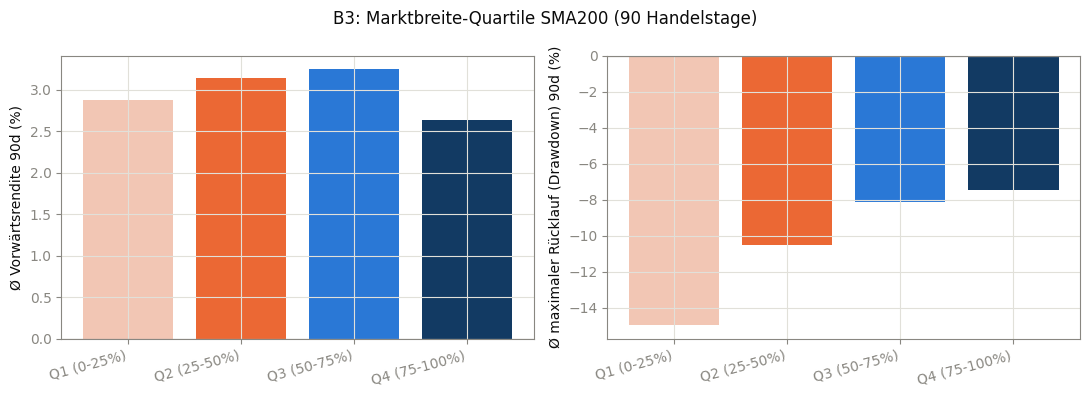

In [17]:
for w in BREADTH_WINDOWS:
    teil_b3 = tabelle_b3[tabelle_b3["sma_fenster"] == w]
    plotte_quartile(teil_b3, 90, f"B3: Marktbreite-Quartile SMA{w} (90 Handelstage)")


**Ergebnis:** Alle 18 Kruskal-Wallis-Omnibustests sind signifikant - die
Marktbreite differenziert die Folgeperiode in jedem Fenster und Horizont
über die vier Quartile hinweg. Beim Risiko zeigt sich, besonders deutlich
bei SMA200, ein sauberer monotoner Gradient von Q1 (schwächste Breite, im
Mittel größter 90-Tage-Drawdown von -15,0 %) über Q2 (-10,5 %) und Q3
(-8,1 %) bis Q4 (stärkste Breite, -7,5 %); bei SMA20/50 ist der Gradient
etwas weniger klar, aber in dieselbe Richtung ausgeprägt. Bei der Rendite
zeigt sich ein Extremquartil-Effekt vor allem bei SMA20 und SMA50: Q1 liefert
dort durchgehend die **höchste** mittlere Vorwärtsrendite aller vier
Quartile (SMA50/90 Tage: 5,8 % gegenüber 2,3-2,9 % in Q2-Q4). Bei SMA200
schwächt sich dieser Effekt mit zunehmendem Horizont ab und kehrt sich bei
90 Tagen leicht um (Q1: 2,9 %, Q3 mit 3,3 % am höchsten, Q4: 2,6 %) - die
extrem schwache Breite ist damit kein durchgehend verlässlicher
Renditetreiber, während der Risikozusammenhang über alle drei Fenster
robust bleibt.


### 4.4 B4 - Frühindikator Krise

**Hypothese:** Ausgangslage ist eine breit getragene Rally (SMA200-Breite
> 75 %, bei intaktem SMA20-Breitewert von mindestens 50 %). Fällt die
schnelle SMA20-Breite anschließend unter 50 %, während die träge
SMA200-Breite selbst noch nicht unter 50 % gefallen ist, deutet dies auf eine
beginnende, aber von der breiten Marktlage noch nicht bestätigte Abkühlung
hin - ein möglicher Frühindikator für eine bevorstehende Krise.


In [18]:
def frühindikator_krise(breite_sma20: pd.Series, breite_sma200: pd.Series) -> pd.Series:
    '''Signalisiert den Tag, an dem die SMA20-Breite erstmals unter 50 %
    fällt, nachdem die SMA200-Breite zuvor (bei damals noch >= 50 % liegender
    SMA20-Breite) das obere Quartil (> 75 %) erreicht hatte und selbst noch
    nicht unter 50 % gefallen ist.'''
    signal = pd.Series(False, index=breite_sma20.index)
    war_oben = False
    for datum in breite_sma20.index:
        b20, b200 = breite_sma20[datum], breite_sma200[datum]
        if pd.isna(b20) or pd.isna(b200):
            continue
        if b200 <= 50:
            war_oben = False
            continue
        if b200 > 75 and b20 >= 50:
            war_oben = True
        if war_oben and b20 < 50:
            signal[datum] = True
            war_oben = False
    return signal


signal_b4 = frühindikator_krise(df["breite_sma20"], df["breite_sma200"])
n_b4 = int(signal_b4.sum())
print(f"B4-Ereignisse identifiziert: {n_b4}")
if n_b4 > 0:
    print(df.index[signal_b4].date)


B4-Ereignisse identifiziert: 145
[datetime.date(2007, 1, 5) datetime.date(2007, 1, 25)
 datetime.date(2007, 2, 9) datetime.date(2007, 2, 23)
 datetime.date(2007, 6, 6) datetime.date(2007, 6, 20)
 datetime.date(2007, 7, 10) datetime.date(2007, 7, 26)
 datetime.date(2007, 10, 16) datetime.date(2007, 10, 30)
 datetime.date(2007, 11, 1) datetime.date(2009, 8, 17)
 datetime.date(2009, 9, 1) datetime.date(2009, 10, 1)
 datetime.date(2009, 10, 26) datetime.date(2009, 10, 30)
 datetime.date(2009, 12, 8) datetime.date(2009, 12, 17)
 datetime.date(2010, 1, 21) datetime.date(2010, 4, 27)
 datetime.date(2010, 4, 30) datetime.date(2010, 5, 4)
 datetime.date(2010, 11, 16) datetime.date(2010, 11, 22)
 datetime.date(2011, 1, 28) datetime.date(2011, 2, 23)
 datetime.date(2011, 3, 1) datetime.date(2011, 3, 4)
 datetime.date(2011, 3, 10) datetime.date(2011, 4, 18)
 datetime.date(2011, 5, 17) datetime.date(2011, 6, 22)
 datetime.date(2011, 7, 18) datetime.date(2011, 7, 26)
 datetime.date(2012, 2, 15) date

In [19]:
ergebnisse_b4 = []
if n_b4 >= 10:
    for h in HORIZONS:
        for ziel in ["fwd_return", "fwd_mdd"]:
            res = vergleiche_gruppen(
                df.loc[signal_b4, f"{ziel}_{h}d"], df[f"{ziel}_{h}d"],
                label_a="B4-Signal", label_b="Basisrate (alle Tage)",
            )
            if res:
                res.update({"horizont_tage": h, "zielgröße": ziel, "n_events": n_b4})
                ergebnisse_b4.append(res)
    tabelle_b4 = ergebnisse_zu_tabelle(ergebnisse_b4)
else:
    # Zu wenige Ereignisse für einen belastbaren Test - Einzelereignisse
    # werden stattdessen deskriptiv mit ihrer tatsächlichen Folgeentwicklung
    # aufgelistet.
    einzelereignisse = df.loc[signal_b4, [f"fwd_return_{h}d" for h in HORIZONS] + [f"fwd_mdd_{h}d" for h in HORIZONS]]
    tabelle_b4 = einzelereignisse.reset_index()
    print(f"Nur {n_b4} Ereignisse - deskriptive Einzelbetrachtung statt Signifikanztest:")

alle_ergebnisse["B4_Frühindikator_Krise"] = tabelle_b4
tabelle_b4


,label_a,n_a,mean_a,median_a,std_a,label_b,n_b,mean_b,median_b,std_b,t_pvalue,u_pvalue,signifikant_5pct,horizont_tage,zielgröße,n_events
0,B4-Signal,145,0.0100,0.0170,0.0404,Basisrate (alle Tage),4785,0.0102,0.0168,0.0519,0.9740,0.7587,False,30,fwd_return,145
1,B4-Signal,145,-0.0435,-0.0358,0.0320,Basisrate (alle Tage),4785,-0.0476,-0.0364,0.0418,0.1351,0.5298,False,30,fwd_mdd,145
2,B4-Signal,145,0.0200,0.0247,0.0508,Basisrate (alle Tage),4755,0.0198,0.0279,0.0700,0.9644,0.3755,False,60,fwd_return,145
3,B4-Signal,145,-0.0629,-0.0519,0.0430,Basisrate (alle Tage),4755,-0.0714,-0.0563,0.0575,0.0228,0.2631,False,60,fwd_mdd,145
4,B4-Signal,145,0.0366,0.0390,0.0546,Basisrate (alle Tage),4725,0.0298,0.0353,0.0832,0.1506,0.4810,False,90,fwd_return,145
5,B4-Signal,145,-0.0732,-0.0628,0.0498,Basisrate (alle Tage),4725,-0.0878,-0.0691,0.0664,0.0008,0.0121,True,90,fwd_mdd,145


**Ergebnis:** Mit 145 identifizierten Ereignissen seit 2007 ist das Muster
gut testbar, das Signal erweist sich jedoch überwiegend als neutral: Nur
beim 90-Tage-Drawdown ist der Unterschied signifikant, und dort fällt der
maximale Vorwärtsrücklauf nach dem Signal **kleiner** (nicht größer) aus
als die Basisrate (-7,3 % gegenüber -8,8 %). Bei 30 und 60 Tagen ist der
Risikounterschied nicht signifikant, die Vorwärtsrendite liegt in allen drei
Horizonten zwar tendenziell etwas höher als die Basisrate, jedoch in keinem
Fall signifikant. Die als Frühindikator einer Krise formulierte Hypothese
bestätigt sich in den Daten damit **nicht** - so weit überhaupt ein Effekt
sichtbar wird (90-Tage-Risiko), zeigt er in die dem Hypothesentext
entgegengesetzte Richtung: ein kurzzeitiger Rücksetzer der schnellen Breite
bei intakter breiter Beteiligung markiert eher eine gesunde Verschnaufpause
als den Auftakt einer Krise. Mit 145 Ereignissen in nicht ganz 20 Jahren
(im Schnitt etwa alle sieben Wochen) ist das Muster zudem ohnehin deutlich
häufiger, als der Name "Frühindikator Krise" vermuten lässt.


### 4.5 B5 - Frühindikator Erholung

**Hypothese:** Spiegelbild zu B4. Ausgangslage ist eine breit unterstützte
Schwächephase (SMA200-Breite < 25 %, bei damals noch schwacher
SMA20-Breite <= 50 %). Steigt die schnelle SMA20-Breite anschließend über
50 %, während die SMA200-Breite selbst noch nicht über 50 % gestiegen ist,
deutet dies auf eine beginnende, breitenseitig noch nicht bestätigte
Erholung hin.


In [20]:
def frühindikator_erholung(breite_sma20: pd.Series, breite_sma200: pd.Series) -> pd.Series:
    signal = pd.Series(False, index=breite_sma20.index)
    war_unten = False
    for datum in breite_sma20.index:
        b20, b200 = breite_sma20[datum], breite_sma200[datum]
        if pd.isna(b20) or pd.isna(b200):
            continue
        if b200 >= 50:
            war_unten = False
            continue
        if b200 < 25 and b20 <= 50:
            war_unten = True
        if war_unten and b20 > 50:
            signal[datum] = True
            war_unten = False
    return signal


signal_b5 = frühindikator_erholung(df["breite_sma20"], df["breite_sma200"])
n_b5 = int(signal_b5.sum())
print(f"B5-Ereignisse identifiziert: {n_b5}")
if n_b5 > 0:
    print(df.index[signal_b5].date)


B5-Ereignisse identifiziert: 46
[datetime.date(2008, 1, 31) datetime.date(2008, 2, 12)
 datetime.date(2008, 2, 22) datetime.date(2008, 3, 11)
 datetime.date(2008, 3, 13) datetime.date(2008, 3, 18)
 datetime.date(2008, 3, 20) datetime.date(2008, 3, 31)
 datetime.date(2008, 7, 17) datetime.date(2008, 7, 22)
 datetime.date(2008, 7, 29) datetime.date(2008, 8, 20)
 datetime.date(2008, 9, 8) datetime.date(2008, 9, 12)
 datetime.date(2008, 10, 31) datetime.date(2008, 11, 28)
 datetime.date(2008, 12, 5) datetime.date(2008, 12, 30)
 datetime.date(2009, 2, 6) datetime.date(2009, 4, 21)
 datetime.date(2009, 4, 23) datetime.date(2009, 5, 26)
 datetime.date(2010, 7, 9) datetime.date(2010, 9, 1)
 datetime.date(2011, 8, 26) datetime.date(2011, 9, 7)
 datetime.date(2011, 9, 15) datetime.date(2011, 9, 27)
 datetime.date(2011, 10, 6) datetime.date(2015, 9, 15)
 datetime.date(2015, 9, 21) datetime.date(2015, 10, 2)
 datetime.date(2016, 1, 29) datetime.date(2016, 2, 16)
 datetime.date(2019, 1, 4) datetime

In [21]:
ergebnisse_b5 = []
if n_b5 >= 10:
    for h in HORIZONS:
        for ziel in ["fwd_return", "fwd_mdd"]:
            res = vergleiche_gruppen(
                df.loc[signal_b5, f"{ziel}_{h}d"], df[f"{ziel}_{h}d"],
                label_a="B5-Signal", label_b="Basisrate (alle Tage)",
            )
            if res:
                res.update({"horizont_tage": h, "zielgröße": ziel, "n_events": n_b5})
                ergebnisse_b5.append(res)
    tabelle_b5 = ergebnisse_zu_tabelle(ergebnisse_b5)
else:
    einzelereignisse = df.loc[signal_b5, [f"fwd_return_{h}d" for h in HORIZONS] + [f"fwd_mdd_{h}d" for h in HORIZONS]]
    tabelle_b5 = einzelereignisse.reset_index()
    print(f"Nur {n_b5} Ereignisse - deskriptive Einzelbetrachtung statt Signifikanztest:")

alle_ergebnisse["B5_Frühindikator_Erholung"] = tabelle_b5
tabelle_b5


,label_a,n_a,mean_a,median_a,std_a,label_b,n_b,mean_b,median_b,std_b,t_pvalue,u_pvalue,signifikant_5pct,horizont_tage,zielgröße,n_events
0,B5-Signal,46,0.0215,0.0444,0.0790,Basisrate (alle Tage),4785,0.0102,0.0168,0.0519,0.3382,0.0146,False,30,fwd_return,46
1,B5-Signal,46,-0.0655,-0.0461,0.0613,Basisrate (alle Tage),4785,-0.0476,-0.0364,0.0418,0.0536,0.0241,False,30,fwd_mdd,46
2,B5-Signal,46,-0.0090,0.0383,0.1263,Basisrate (alle Tage),4755,0.0198,0.0279,0.0700,0.1288,0.8932,False,60,fwd_return,46
3,B5-Signal,46,-0.1216,-0.0810,0.0945,Basisrate (alle Tage),4755,-0.0714,-0.0563,0.0575,0.0008,0.0000,True,60,fwd_mdd,46
4,B5-Signal,46,0.0025,0.0244,0.1437,Basisrate (alle Tage),4725,0.0298,0.0353,0.0832,0.2041,0.6198,False,90,fwd_return,46
5,B5-Signal,46,-0.1508,-0.1230,0.1043,Basisrate (alle Tage),4725,-0.0878,-0.0691,0.0664,0.0002,0.0000,True,90,fwd_mdd,46


**Ergebnis:** 46 Ereignisse seit 2007, historisch plausibel rund um reale
Bodenbildungsphasen konzentriert (2008/2009, 2011, 2015/2016, 2019/2020,
2022). Bei der Rendite zeigt sich kein einheitliches Bild: Bei 30 Tagen
liegt sie im Mittel etwas höher als die Basisrate (2,2 % gegenüber 1,0 %),
bei 60 und 90 Tagen dagegen niedriger oder etwa gleichauf (60 Tage: -0,9 %
gegenüber 2,0 %; 90 Tage: 0,3 % gegenüber 3,0 %) - in keinem der drei
Horizonte ist der Unterschied signifikant. Der maximale Vorwärtsrücklauf ist
dagegen bei 60 und 90 Tagen signifikant **größer** als die Basisrate
(60 Tage: -12,2 % gegenüber -7,1 %; 90 Tage: -15,1 % gegenüber -8,8 %) -
also das Gegenteil dessen, was eine "ruhige Erholung" nahelegen würde; bei
30 Tagen ist der Unterschied nicht signifikant. Das Signal fällt damit nicht
mit einer risikoarmen, renditestarken Erholung zusammen, sondern mit
anhaltend erhöhter Volatilität innerhalb noch nicht abgeschlossener
Bodenbildungsphasen - ein früher Hinweis auf Instabilität, nicht auf eine
bevorstehende ruhige Erholung.


### 4.6 Gemeinsames Vorgehen für B6-B9

Die folgenden vier Hypothesen basieren alle auf punktuellen Ereignissen
(Schwellenkreuzungen). Sie werden mit derselben Funktion ausgewertet: Bei
mindestens 10 Ereignissen wird das Ereignis gegen die Basisrate (alle
Handelstage) getestet, bei weniger Ereignissen erfolgt eine deskriptive
Auflistung der Einzelereignisse.


In [22]:
def ereignis_hypothese(event: pd.Series, label: str, extra: dict) -> tuple[list[dict], pd.DataFrame | None]:
    '''Testet ein Ereignis (event=True an den Signaltagen) gegen die
    Basisrate aller Handelstage. Liefert (Ergebnisliste, None) bei
    ausreichender Stichprobe, sonst (leere Liste, Tabelle der
    Einzelereignisse) zur deskriptiven Auflistung.'''
    n = int(event.sum())
    if n >= 10:
        ergebnisse = []
        for h in HORIZONS:
            for ziel in ["fwd_return", "fwd_mdd"]:
                res = vergleiche_gruppen(
                    df.loc[event, f"{ziel}_{h}d"], df[f"{ziel}_{h}d"],
                    label_a=label, label_b="Basisrate (alle Tage)",
                )
                if res:
                    res.update({**extra, "horizont_tage": h, "zielgröße": ziel, "n_events": n})
                    ergebnisse.append(res)
        return ergebnisse, None
    else:
        spalten = [f"fwd_return_{h}d" for h in HORIZONS] + [f"fwd_mdd_{h}d" for h in HORIZONS]
        einzel = df.loc[event, spalten].reset_index()
        for k, v in extra.items():
            einzel[k] = v
        return [], einzel


print("Gemeinsame Ereignis-Testfunktion definiert.")


Gemeinsame Ereignis-Testfunktion definiert.


### 4.7 B6 - Wochentrend positiv, Marktbreite bricht ein

**Hypothese:** Steigt der Index auf Wochenbasis (Kurs > SMA50_w, ca. 1 Jahr),
die Marktbreite je SMA-Fenster jedoch gleichzeitig (a) aus dem oberen
Quartil heraus oder (b) unter 50 % - deutet dies auf eine zunehmend schmaler
getragene Rally hin, obwohl der Index selbst noch keinen Trendbruch zeigt.
Jedes Fenster (SMA20/50/200) wird einzeln betrachtet.


In [23]:
def kreuzt_abwärts(reihe: pd.Series, schwelle: float) -> pd.Series:
    vorher = reihe.shift(1)
    return (vorher >= schwelle) & (reihe < schwelle)


wochentrend_positiv = df["Wochentrend_positiv"] == 1

ergebnisse_b6 = []
deskriptiv_b6 = []
n_events_b6 = {}
for w in BREADTH_WINDOWS:
    breite = df[f"breite_sma{w}"]
    for schwelle, bezeichnung in [(75, "verlässt oberes Quartil (75%)"), (50, "fällt unter 50%")]:
        event = kreuzt_abwärts(breite, schwelle) & wochentrend_positiv
        label = f"B6 SMA{w} {bezeichnung}"
        n_events_b6[label] = int(event.sum())
        ergebnisse, deskriptiv = ereignis_hypothese(
            event, label, {"sma_fenster": w, "schwelle": schwelle, "bezeichnung": bezeichnung},
        )
        ergebnisse_b6.extend(ergebnisse)
        if deskriptiv is not None:
            deskriptiv_b6.append(deskriptiv)

print("Ereignishäufigkeit je Parametrisierung:")
for label, n in n_events_b6.items():
    print(f"  {label:.<55s} {n}")

tabelle_b6 = ergebnisse_zu_tabelle(ergebnisse_b6)
alle_ergebnisse["B6_Wochentrend_positiv_Breiteneinbruch"] = tabelle_b6
tabelle_deskriptiv_b6 = pd.concat(deskriptiv_b6, ignore_index=True) if deskriptiv_b6 else pd.DataFrame()
if not tabelle_b6.empty:
    display(tabelle_b6[["sma_fenster", "bezeichnung", "n_events", "horizont_tage", "zielgröße",
                         "mean_a", "mean_b", "t_pvalue", "u_pvalue", "signifikant_5pct"]])
if not tabelle_deskriptiv_b6.empty:
    print("\nDeskriptiv (weniger als 10 Ereignisse):")
    display(tabelle_deskriptiv_b6)


Ereignishäufigkeit je Parametrisierung:
  B6 SMA20 verlässt oberes Quartil (75%)................. 233
  B6 SMA20 fällt unter 50%............................... 225
  B6 SMA50 verlässt oberes Quartil (75%)................. 140
  B6 SMA50 fällt unter 50%............................... 149
  B6 SMA200 verlässt oberes Quartil (75%)................ 125
  B6 SMA200 fällt unter 50%.............................. 42


,sma_fenster,bezeichnung,n_events,horizont_tage,zielgröße,mean_a,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,20,verlässt oberes Quartil (75%),233,30,fwd_return,0.0133,0.0102,0.1911,0.6196,False
1,20,verlässt oberes Quartil (75%),233,30,fwd_mdd,-0.0378,-0.0476,0.0000,0.0008,True
2,20,verlässt oberes Quartil (75%),233,60,fwd_return,0.0269,0.0198,0.0450,0.2656,False
3,20,verlässt oberes Quartil (75%),233,60,fwd_mdd,-0.0533,-0.0714,0.0000,0.0000,True
4,20,verlässt oberes Quartil (75%),233,90,fwd_return,0.0357,0.0298,0.1800,0.4043,False
5,20,verlässt oberes Quartil (75%),233,90,fwd_mdd,-0.0691,-0.0878,0.0000,0.0000,True
6,20,fällt unter 50%,225,30,fwd_return,0.0078,0.0102,0.5035,0.8794,False
7,20,fällt unter 50%,225,30,fwd_mdd,-0.0464,-0.0476,0.7085,0.4808,False
8,20,fällt unter 50%,225,60,fwd_return,0.0197,0.0198,0.9787,0.4531,False
9,20,fällt unter 50%,225,60,fwd_mdd,-0.0651,-0.0714,0.0931,0.1112,False


**Ergebnis:** Alle sechs Parametrisierungen sind mit 42 bis 233 Ereignissen
gut testbar. Die Rendite unterscheidet sich in keiner der 18 Kombinationen
signifikant von der Basisrate. Beim Risiko zeigt sich ein signifikanter
Unterschied ausschließlich bei SMA20 (4 von 18 Kombinationen: alle drei
Horizonte bei "verlässt oberes Quartil", zusätzlich der 90-Tage-Horizont bei
"fällt unter 50 %") - und zwar in die dem Hypothesentext
**entgegengesetzte** Richtung: Der nachfolgende maximale Rücklauf fällt nach
dem Signal kleiner aus als die Basisrate (z. B. SMA20 "verlässt oberes
Quartil", 90 Tage: -6,9 % gegenüber -8,8 %). Bei SMA50 und SMA200 ist kein
einziger der 24 verbleibenden Vergleiche signifikant. Ein sich
abschwächender, aber noch positiver Wochentrend liefert damit kein
belastbares Frühwarnsignal über eine schmaler werdende Rally - soweit
überhaupt ein Effekt sichtbar wird, deutet er (wie bereits bei B4) eher auf
eine gesunde Verschnaufpause hin.


### 4.8 B7 - Wochentrend negativ, Marktbreite stabilisiert sich

**Hypothese:** Spiegelbild zu B6. Fällt der Index auf Wochenbasis (Kurs <=
SMA50_w), die Marktbreite je SMA-Fenster jedoch (a) aus dem unteren Quartil
heraus oder (b) über 50 % - deutet dies auf eine zunehmend breiter
getragene Stabilisierung hin, obwohl der Index selbst noch keinen
Trendwechsel zeigt.


In [24]:
def kreuzt_aufwärts(reihe: pd.Series, schwelle: float) -> pd.Series:
    vorher = reihe.shift(1)
    return (vorher <= schwelle) & (reihe > schwelle)


wochentrend_negativ = df["Wochentrend_positiv"] == 0

ergebnisse_b7 = []
deskriptiv_b7 = []
n_events_b7 = {}
for w in BREADTH_WINDOWS:
    breite = df[f"breite_sma{w}"]
    for schwelle, bezeichnung in [(25, "verlässt unteres Quartil (25%)"), (50, "steigt über 50%")]:
        event = kreuzt_aufwärts(breite, schwelle) & wochentrend_negativ
        label = f"B7 SMA{w} {bezeichnung}"
        n_events_b7[label] = int(event.sum())
        ergebnisse, deskriptiv = ereignis_hypothese(
            event, label, {"sma_fenster": w, "schwelle": schwelle, "bezeichnung": bezeichnung},
        )
        ergebnisse_b7.extend(ergebnisse)
        if deskriptiv is not None:
            deskriptiv_b7.append(deskriptiv)

print("Ereignishäufigkeit je Parametrisierung:")
for label, n in n_events_b7.items():
    print(f"  {label:.<55s} {n}")

tabelle_b7 = ergebnisse_zu_tabelle(ergebnisse_b7)
alle_ergebnisse["B7_Wochentrend_negativ_Breitenstabilisierung"] = tabelle_b7
tabelle_deskriptiv_b7 = pd.concat(deskriptiv_b7, ignore_index=True) if deskriptiv_b7 else pd.DataFrame()
if not tabelle_b7.empty:
    display(tabelle_b7[["sma_fenster", "bezeichnung", "n_events", "horizont_tage", "zielgröße",
                         "mean_a", "mean_b", "t_pvalue", "u_pvalue", "signifikant_5pct"]])
if not tabelle_deskriptiv_b7.empty:
    print("\nDeskriptiv (weniger als 10 Ereignisse):")
    display(tabelle_deskriptiv_b7)


Ereignishäufigkeit je Parametrisierung:
  B7 SMA20 verlässt unteres Quartil (25%)................ 62
  B7 SMA20 steigt über 50%............................... 68
  B7 SMA50 verlässt unteres Quartil (25%)................ 43
  B7 SMA50 steigt über 50%............................... 44
  B7 SMA200 verlässt unteres Quartil (25%)............... 55
  B7 SMA200 steigt über 50%.............................. 20


,sma_fenster,bezeichnung,n_events,horizont_tage,zielgröße,mean_a,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,20,verlässt unteres Quartil (25%),62,30,fwd_return,0.0113,0.0102,0.9168,0.0704,False
1,20,verlässt unteres Quartil (25%),62,30,fwd_mdd,-0.0811,-0.0476,0.0006,0.0000,True
2,20,verlässt unteres Quartil (25%),62,60,fwd_return,0.0254,0.0198,0.6839,0.0723,False
3,20,verlässt unteres Quartil (25%),62,60,fwd_mdd,-0.1095,-0.0714,0.0004,0.0000,True
4,20,verlässt unteres Quartil (25%),62,90,fwd_return,0.0193,0.0298,0.5828,0.3279,False
5,20,verlässt unteres Quartil (25%),62,90,fwd_mdd,-0.1332,-0.0878,0.0004,0.0000,True
6,20,steigt über 50%,68,30,fwd_return,0.0068,0.0102,0.7486,0.3490,False
7,20,steigt über 50%,68,30,fwd_mdd,-0.0748,-0.0476,0.0004,0.0000,True
8,20,steigt über 50%,68,60,fwd_return,-0.0019,0.0198,0.1459,0.9006,False
9,20,steigt über 50%,68,60,fwd_mdd,-0.1184,-0.0714,0.0000,0.0000,True


**Ergebnis:** Ereignishäufigkeiten liegen zwischen 20 und 68 - durchgehend
gut testbar. Die Rendite unterscheidet sich in keiner der 18 Kombinationen
signifikant von der Basisrate. Beim Risiko zeigt sich dagegen ein
durchgehend signifikanter Unterschied bei SMA20, SMA50 und größtenteils bei
SMA200 (14 von 18 Kombinationen, einzige Ausnahme: SMA200 "steigt über
50 %", mit n=20 die kleinste Parametrisierung, in keinem Horizont
signifikant) - und zwar wie schon bei B5 in die unerwartete Richtung: Der
maximale Vorwärtsrücklauf fällt **größer** statt kleiner aus (z. B. SMA200
"verlässt unteres Quartil", 90 Tage: -15,1 % gegenüber -8,8 % Basisrate).
Ein sich bereits aufhellender, aber noch negativer Wochentrend geht damit
historisch nicht mit einer risikoärmeren Erholung einher, sondern mit
anhaltend erhöhter Volatilität - inhaltlich dasselbe Muster wie bei B5, hier
jedoch mit deutlich größeren Stichproben statistisch breiter abgesichert.


### 4.9 B8 - Divergenz: Kurshoch ohne Breitenbestätigung

**Hypothese:** Erreicht der Index ein neues Hoch der letzten w Handelstage,
ist relevant, ob die zugehörige Marktbreite (SMA-Fenster w) diese Bewegung
bestätigt (in den letzten 10 Handelstagen gestiegen) oder nicht (gefallen
oder unverändert). Eine unbestätigte Rally (steigender Kurs, fallende
Beteiligung) gilt in der technischen Analyse als Warnsignal.


In [25]:
DIVERGENZ_LAG = 10

ergebnisse_b8 = []
deskriptiv_b8 = []
for w in BREADTH_WINDOWS:
    breite = df[f"breite_sma{w}"]
    kurshoch = df["Close"] >= df["Close"].rolling(window=w, min_periods=w).max()
    bestätigt = kurshoch & (breite > breite.shift(DIVERGENZ_LAG))
    nicht_bestätigt = kurshoch & (breite <= breite.shift(DIVERGENZ_LAG))
    print(f"SMA{w}: {int(kurshoch.sum())} {w}-Tage-Hochs, davon "
          f"{int(bestätigt.sum())} breitenbestätigt und {int(nicht_bestätigt.sum())} unbestätigt.")

    for h in HORIZONS:
        for ziel in ["fwd_return", "fwd_mdd"]:
            res = vergleiche_gruppen(
                df.loc[bestätigt, f"{ziel}_{h}d"], df.loc[nicht_bestätigt, f"{ziel}_{h}d"],
                label_a=f"{w}-Tage-Hoch, Breite bestätigt", label_b=f"{w}-Tage-Hoch, Breite nicht bestätigt",
            )
            if res:
                res.update({"sma_fenster": w, "horizont_tage": h, "zielgröße": ziel,
                             "n_bestätigt": int(bestätigt.sum()), "n_nicht_bestätigt": int(nicht_bestätigt.sum())})
                ergebnisse_b8.append(res)

    if int(bestätigt.sum()) < 10 or int(nicht_bestätigt.sum()) < 10:
        spalten = [f"fwd_return_{h}d" for h in HORIZONS] + [f"fwd_mdd_{h}d" for h in HORIZONS]
        einzel = df.loc[kurshoch, spalten + []].reset_index()
        einzel["sma_fenster"] = w
        einzel["breite_bestätigt"] = bestätigt.loc[kurshoch].values
        deskriptiv_b8.append(einzel)

tabelle_b8 = ergebnisse_zu_tabelle(ergebnisse_b8)
alle_ergebnisse["B8_Divergenz_Kurshoch_Breite"] = tabelle_b8
tabelle_deskriptiv_b8 = pd.concat(deskriptiv_b8, ignore_index=True) if deskriptiv_b8 else pd.DataFrame()
if not tabelle_b8.empty:
    display(tabelle_b8[["sma_fenster", "horizont_tage", "zielgröße", "n_bestätigt", "n_nicht_bestätigt",
                         "mean_a", "mean_b", "t_pvalue", "u_pvalue", "signifikant_5pct"]])


SMA20: 987 20-Tage-Hochs, davon 706 breitenbestätigt und 281 unbestätigt.
SMA50: 724 50-Tage-Hochs, davon 518 breitenbestätigt und 206 unbestätigt.
SMA200: 507 200-Tage-Hochs, davon 307 breitenbestätigt und 200 unbestätigt.


,sma_fenster,horizont_tage,zielgröße,n_bestätigt,n_nicht_bestätigt,mean_a,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,20,30,fwd_return,706,281,0.0079,0.0082,0.8928,0.8650,False
1,20,30,fwd_mdd,706,281,-0.0404,-0.0394,0.6531,0.7235,False
2,20,60,fwd_return,706,281,0.0161,0.0161,0.9897,0.9209,False
3,20,60,fwd_mdd,706,281,-0.0630,-0.0638,0.8401,0.8842,False
4,20,90,fwd_return,706,281,0.0259,0.0158,0.0688,0.3033,False
5,20,90,fwd_mdd,706,281,-0.0807,-0.0877,0.1600,0.2755,False
6,50,30,fwd_return,518,206,0.0071,0.0023,0.1749,0.5253,False
7,50,30,fwd_mdd,518,206,-0.0381,-0.0423,0.1489,0.3347,False
8,50,60,fwd_return,518,206,0.0154,0.0123,0.5410,0.8330,False
9,50,60,fwd_mdd,518,206,-0.0593,-0.0669,0.1046,0.0197,False


**Ergebnis:** Die große Mehrheit der Hochs ist breitenbestätigt (SMA20:
706 von 987; SMA50: 518 von 724; SMA200: 307 von 507). Bei SMA20 und SMA50
ist keine der zwölf Kombinationen signifikant. Bei SMA200 sind dagegen genau
zwei Kombinationen signifikant - beide beim 30-Tage-Horizont - und hier
zeigt sich die klassische Warnung tatsächlich bestätigt: Nach einem
breitenbestätigten Hoch fällt die 30-Tage-Vorwärtsrendite **höher** aus als
nach einem unbestätigten (0,9 % gegenüber -0,1 %), und der 30-Tage-Drawdown
fällt gleichzeitig **kleiner** aus (-3,4 % gegenüber -4,4 %). Bei 60 und
90 Tagen verschwindet dieser Unterschied bei SMA200 wieder. Anders als bei
den übrigen Ereignishypothesen (B4, B6, B7) zeigt sich bei B8 damit kein
durchgehendes Mean-Reversion-Muster: Für den langfristigen SMA200 stützt der
kurzfristige Horizont die klassische Warnung vor einer "nicht bestätigten
Rally", während für SMA20/SMA50 in keinem Horizont ein signifikanter
Unterschied nachweisbar ist.


### 4.10 B9 - Breadth Thrust und Breadth Collapse

**Hypothese:** Ein schneller Anstieg der Marktbreite von unter 40 % auf über
60 % innerhalb von 10 Handelstagen (Breadth Thrust) gilt in der technischen
Analyse als seltenes, aber kräftiges Kaufsignal (Konzept angelehnt an den
Zweig Breadth Thrust). Der Einbruch von über 60 % auf unter 40 % innerhalb
derselben Frist (Breadth Collapse) wäre das entsprechende Warnsignal.


In [26]:
THRUST_FENSTER = 10
THRUST_UNTEN, THRUST_OBEN = 40, 60

ergebnisse_b9 = []
deskriptiv_b9 = []
n_events_b9 = {}
for w in BREADTH_WINDOWS:
    breite = df[f"breite_sma{w}"]
    minimum_vorher = breite.shift(1).rolling(window=THRUST_FENSTER, min_periods=THRUST_FENSTER).min()
    maximum_vorher = breite.shift(1).rolling(window=THRUST_FENSTER, min_periods=THRUST_FENSTER).max()

    thrust = (breite >= THRUST_OBEN) & (minimum_vorher <= THRUST_UNTEN)
    collapse = (breite <= THRUST_UNTEN) & (maximum_vorher >= THRUST_OBEN)

    for event, label in [(thrust, f"B9 SMA{w} Breadth Thrust"), (collapse, f"B9 SMA{w} Breadth Collapse")]:
        n_events_b9[label] = int(event.sum())
        ergebnisse, deskriptiv = ereignis_hypothese(event, label, {"sma_fenster": w, "muster": label})
        ergebnisse_b9.extend(ergebnisse)
        if deskriptiv is not None:
            deskriptiv_b9.append(deskriptiv)

print("Ereignishäufigkeit je Parametrisierung:")
for label, n in n_events_b9.items():
    print(f"  {label:.<40s} {n}")

tabelle_b9 = ergebnisse_zu_tabelle(ergebnisse_b9)
alle_ergebnisse["B9_Breadth_Thrust_Collapse"] = tabelle_b9
tabelle_deskriptiv_b9 = pd.concat(deskriptiv_b9, ignore_index=True) if deskriptiv_b9 else pd.DataFrame()
if not tabelle_b9.empty:
    display(tabelle_b9[["sma_fenster", "muster", "n_events", "horizont_tage", "zielgröße",
                         "mean_a", "mean_b", "t_pvalue", "u_pvalue", "signifikant_5pct"]])
if not tabelle_deskriptiv_b9.empty:
    print("\nDeskriptiv (weniger als 10 Ereignisse):")
    display(tabelle_deskriptiv_b9)


Ereignishäufigkeit je Parametrisierung:
  B9 SMA20 Breadth Thrust................. 1031
  B9 SMA20 Breadth Collapse............... 777
  B9 SMA50 Breadth Thrust................. 437
  B9 SMA50 Breadth Collapse............... 401
  B9 SMA200 Breadth Thrust................ 66
  B9 SMA200 Breadth Collapse.............. 65


,sma_fenster,muster,n_events,horizont_tage,zielgröße,mean_a,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,20,B9 SMA20 Breadth Thrust,1031,30,fwd_return,0.0063,0.0102,0.0304,0.0382,True
1,20,B9 SMA20 Breadth Thrust,1031,30,fwd_mdd,-0.0473,-0.0476,0.8483,0.7918,False
2,20,B9 SMA20 Breadth Thrust,1031,60,fwd_return,0.0170,0.0198,0.2298,0.4271,False
3,20,B9 SMA20 Breadth Thrust,1031,60,fwd_mdd,-0.0703,-0.0714,0.5734,0.4318,False
4,20,B9 SMA20 Breadth Thrust,1031,90,fwd_return,0.0272,0.0298,0.3263,0.0707,False
5,20,B9 SMA20 Breadth Thrust,1031,90,fwd_mdd,-0.0863,-0.0878,0.4962,0.8826,False
6,20,B9 SMA20 Breadth Collapse,777,30,fwd_return,0.0175,0.0102,0.0005,0.0000,True
7,20,B9 SMA20 Breadth Collapse,777,30,fwd_mdd,-0.0503,-0.0476,0.0994,0.0135,False
8,20,B9 SMA20 Breadth Collapse,777,60,fwd_return,0.0316,0.0198,0.0000,0.0000,True
9,20,B9 SMA20 Breadth Collapse,777,60,fwd_mdd,-0.0709,-0.0714,0.8400,0.5484,False


**Ergebnis:** **Breadth Thrust** (rasche Ausweitung) zeigt ein je nach
Fenster sehr unterschiedliches Bild. Bei SMA50 (437 Ereignisse) ist keine
der sechs Kombinationen signifikant. Bei SMA20 (1.031 Ereignisse) ist die
30-Tage-Rendite signifikant, jedoch **niedriger** statt höher als die
Basisrate (0,6 % gegenüber 1,0 %) - das Gegenteil eines Kaufsignals. Bei
SMA200 dagegen (66 Ereignisse) bestätigt sich die Hypothese klar: Die
Vorwärtsrendite ist in allen drei Horizonten signifikant **höher** als die
Basisrate (90 Tage: 7,2 % gegenüber 3,0 %), und bei 60/90 Tagen ist
zusätzlich das Risiko signifikant **niedriger** (90 Tage: -6,1 % gegenüber
-8,8 %) - ein echtes, robust bestätigtes bullishes Signal mit
unterdurchschnittlichem Risiko, allerdings nur auf dem langfristigen Fenster.
**Breadth Collapse** (rascher Einbruch) zeigt dagegen fensterübergreifend
ein konsistenteres Muster: Die Vorwärtsrendite ist bei SMA20 (777
Ereignisse) in allen drei Horizonten signifikant höher als die Basisrate
(90 Tage: 4,4 % gegenüber 3,0 %), ebenso bei SMA50 (401 Ereignisse, 60/90
Tage) und SMA200 (65 Ereignisse, 60/90 Tage). Beim Risiko zeigt sich dagegen
ein uneinheitliches Bild: Bei SMA20 ist kein Horizont signifikant, bei SMA50
und SMA200 dagegen ist der Drawdown bei 30/60 Tagen signifikant **größer**
als die Basisrate (SMA50/30 Tage: -6,0 % gegenüber -4,8 %) - ein rascher
Breiteneinbruch fällt historisch mit kurzfristigen Panikphasen zusammen,
auf die im Mittel eine überdurchschnittliche Erholung folgt, bei den
längeren Fenstern jedoch verbunden mit zunächst erhöhtem Risiko. Anders als
bei den übrigen Ereignishypothesen ist bei B9 damit häufiger die Rendite als
das Risiko signifikant betroffen - ein klassisches Risiko-Rendite-Muster
statt eines reinen Warnsignals, mit dem SMA200-Breadth-Thrust als
bemerkenswerter Einzelfall eines tatsächlich bestätigten, risikoarmen
Kaufsignals.


### 4.11 Übergreifende Robustheitsübersicht

Fasst über alle getesteten Parametrisierungen je Hypothese den Anteil
signifikanter Kombinationen zusammen - getrennt für Rendite und Risiko.
Ereignishypothesen mit weniger als 10 Fällen (nur deskriptiv ausgewiesen)
tragen keine testbaren Zeilen bei und erscheinen daher ggf. nicht oder nur
mit wenigen Zeilen in dieser Übersicht.


In [27]:
robustheit = []
for name, tabelle in alle_ergebnisse.items():
    if "zielgröße" not in tabelle.columns:
        continue
    # B3 (Quartile) nutzt den Kruskal-Wallis-Omnibustest statt des paarweisen
    # Welch-t-/Mann-Whitney-Verfahrens der übrigen Hypothesen und hat daher
    # eine andere Signifikanzspalte.
    if "signifikant_5pct" in tabelle.columns:
        sig_spalte = "signifikant_5pct"
    elif "kw_signifikant_5pct" in tabelle.columns:
        sig_spalte = "kw_signifikant_5pct"
    else:
        continue
    for ziel in ["fwd_return", "fwd_mdd"]:
        teil = tabelle[tabelle["zielgröße"] == ziel]
        if len(teil) == 0:
            continue
        robustheit.append({
            "hypothese": name, "zielgröße": ziel,
            "getestete_kombinationen": len(teil),
            "anteil_signifikant": teil[sig_spalte].mean(),
        })

tabelle_robustheit = pd.DataFrame(robustheit)
pivot_robustheit = tabelle_robustheit.pivot(index="hypothese", columns="zielgröße", values="anteil_signifikant")
pivot_robustheit = pivot_robustheit.rename(columns={"fwd_return": "Anteil signifikant (Rendite)",
                                                     "fwd_mdd": "Anteil signifikant (Risiko)"})
pivot_robustheit


zielgröße,Anteil signifikant (Risiko),Anteil signifikant (Rendite)
hypothese,,
B1_Breite_Regime,1.0000,0.6667
B2_Breite_Richtung,0.2222,0.0000
B3_Breite_Quartile,1.0000,1.0000
B4_Frühindikator_Krise,0.3333,0.0000
B5_Frühindikator_Erholung,0.6667,0.0000
B6_Wochentrend_positiv_Breiteneinbruch,0.2222,0.0000
B7_Wochentrend_negativ_Breitenstabilisierung,0.7778,0.0000
B8_Divergenz_Kurshoch_Breite,0.1111,0.1111
B9_Breadth_Thrust_Collapse,0.3333,0.6111


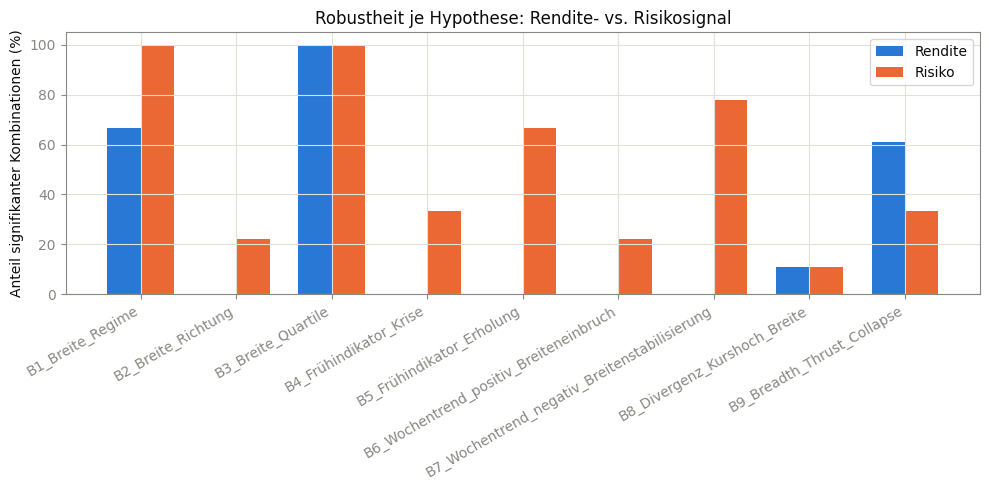

In [28]:
fig, achse = plt.subplots(figsize=(10, 5))
x = np.arange(len(pivot_robustheit))
breite = 0.35
achse.bar(x - breite / 2, pivot_robustheit["Anteil signifikant (Rendite)"] * 100, breite, label="Rendite", color=COLOR_A)
achse.bar(x + breite / 2, pivot_robustheit["Anteil signifikant (Risiko)"] * 100, breite, label="Risiko", color=COLOR_B)
achse.set_xticks(x)
achse.set_xticklabels(pivot_robustheit.index, rotation=30, ha="right")
achse.set_ylabel("Anteil signifikanter Kombinationen (%)")
achse.legend()
plt.title("Robustheit je Hypothese: Rendite- vs. Risikosignal")
plt.tight_layout()
plt.show()


**Ergebnis:** Anteil signifikanter Kombinationen (Risiko / Rendite) je
Hypothese: B1 100 %/67 %, B2 22 %/0 %, B3 100 %/100 %, B4 33 %/0 %, B5
67 %/0 %, B6 22 %/0 %, B7 78 %/0 %, B8 11 %/11 %, B9 33 %/61 %. Bei sechs
der neun Hypothesen (B1, B2, B4, B5, B6, B7) ist das Risikosignal deutlich
häufiger signifikant als das Renditesignal, bei B3 sind beide Achsen
gleichermaßen durchgehend signifikant und bei B8 gleich häufig (aber mit
unterschiedlicher inhaltlicher Aussage, siehe 4.9). Die einzige Ausnahme ist
B9: Dort ist die Rendite deutlich häufiger signifikant als das Risiko
(61 % gegenüber 33 %) - passend zum in 4.10 beschriebenen
Risiko-Rendite-Muster von Breadth Collapse. Insgesamt bestätigt sich das
Bild aus den Einzelhypothesen: Die Marktbreite ist über die meisten
Hypothesen hinweg ein deutlich robusteres Risiko- als Renditesignal, mit B9
als bemerkenswerter Ausnahme.


## 5. Einordnung und Handlungsempfehlungen


Die neun Hypothesen zeigen insgesamt ein klares Grundmuster mit einigen
bemerkenswerten Ausnahmen: Technische Signale auf Basis der Marktbreite
sagen bei den meisten Hypothesen deutlich mehr über das Risiko als über die
Rendite der Folgeperiode aus. In den *sequenziellen* Ereignishypothesen
(B4-B8), die allesamt als Warnsignal formuliert waren, zeigt sich
überwiegend entweder kein Effekt oder ein dem Hypothesentext
**entgegengesetzter** Effekt: B4 (Frühindikator Krise) ist größtenteils
neutral und deutet, soweit überhaupt ein Effekt sichtbar wird, eher auf eine
gesunde Verschnaufpause hin; B5 und B7 (Signale bei negativem Wochentrend)
zeigen konsistent **höheres**, nicht geringeres Risiko - ein Hinweis auf
anhaltend erhöhte Volatilität in ohnehin turbulenten Phasen statt eines
eigenständigen Frühwarnsignals; B6 zeigt nur bei SMA20 ein signifikantes,
dem Hypothesentext entgegengesetztes Risikosignal. Zwei Ausnahmen
durchbrechen dieses Muster: B8 bestätigt für SMA200 auf kurzem Horizont
tatsächlich die klassische Warnung vor einer "nicht bestätigten Rally"
(höheres Risiko, niedrigere Rendite bei unbestätigten Hochs), und B9 zeigt
mit dem SMA200-Breadth-Thrust ein robust bestätigtes, in beide Richtungen
(höhere Rendite, niedrigeres Risiko) wirkendes Kaufsignal. Die
*zustandsbasierten* Hypothesen B1 und B3 (Marktbreite-Niveau) bleiben
dagegen über alle Fenster hinweg die robustesten und am klarsten
interpretierbaren Bausteine.

**Praxisrelevanz:** Für ein Ampelsystem eignet sich die Marktbreite vor
allem als Niveau-Kennzahl (B1/B3), nicht als generischer Trigger für
punktuelle Schwellenkreuzungen. Die in mehreren Hypothesen wiederkehrende
Mean-Reversion-Wirkung (schwache Breite -> im Mittel höhere Folgerendite)
deutet darauf hin, dass kurzfristige Breitensignale mehrheitlich eher
gegenläufig als bestätigend zu interpretieren sind - mit dem SMA200-Breadth-
Thrust und der kurzfristigen SMA200-Divergenz (B8) als bemerkenswerten,
fensterspezifischen Gegenbeispielen, die für ein Ampelsystem gezielt als
ergänzende Bausteine geprüft werden könnten.


## 6. Ampel-Systematik auf Basis der Marktbreite


### 6.1 Bausteine: Breiten-Trend-Score (B1 + B2) und Drawdown-Stufe

Ein **Breiten-Trend-Score** wird aus B1 (Marktbreite-Regime) und B2
(Richtung der Marktbreite) auf dem langfristigen SMA200-Fenster gebildet
und mit einer **Drawdown-Stufe** (Abstand des Index vom bisherigen Hoch)
kombiniert. Die Kombination aus Trend- und Risikoachse soll zeigen, ob die
Marktbreite als eigenständiger Baustein einer Ampel-Systematik einen
Mehrwert liefert.


In [29]:
def trend_score(zustand_gut: pd.Series, zustand_steigend: pd.Series) -> pd.Series:
    # 0 = beide Bedingungen günstig, 2 = beide ungünstig, 1 = gemischt.
    valide = zustand_gut.notna() & zustand_steigend.notna()
    score = pd.Series(np.nan, index=df.index)
    score[valide & zustand_gut & zustand_steigend] = 0
    score[valide & (zustand_gut != zustand_steigend)] = 1
    score[valide & ~zustand_gut & ~zustand_steigend] = 2
    return score


breite_sma200_über_50 = df["breite_sma200"] > 50
breite_sma200_steigend = df["breite_sma200"].diff() > 0
df["Breiten_Trend_Score"] = trend_score(breite_sma200_über_50, breite_sma200_steigend)

# Drawdown-Stufe (Abstand vom bisherigen Hoch), direkt aus dem Indexkurs
# berechnet.
df["Allzeithoch"] = df["Close"].cummax()
df["Abstand_vom_Hoch"] = df["Close"] / df["Allzeithoch"] - 1


def drawdown_bucket(x: float) -> str:
    if x >= -0.05:
        return "Nahe am Hoch (0 bis -5%)"
    elif x >= -0.10:
        return "Leichte Korrektur (-5 bis -10%)"
    elif x >= -0.20:
        return "Korrektur (-10 bis -20%)"
    else:
        return "Bärenmarkt (< -20%)"


df["Drawdown_Bucket"] = df["Abstand_vom_Hoch"].apply(drawdown_bucket)
bucket_reihenfolge = ["Nahe am Hoch (0 bis -5%)", "Leichte Korrektur (-5 bis -10%)",
                      "Korrektur (-10 bis -20%)", "Bärenmarkt (< -20%)"]

print("Verteilung des Breiten-Trend-Score (0 = günstig, 2 = ungünstig):")
print(df["Breiten_Trend_Score"].value_counts().sort_index())


Verteilung des Breiten-Trend-Score (0 = günstig, 2 = ungünstig):
Breiten_Trend_Score
0.0000    1045
1.0000    2949
2.0000     821
Name: count, dtype: int64


### 6.2 Empirische Grundlage der Kategoriengrenzen


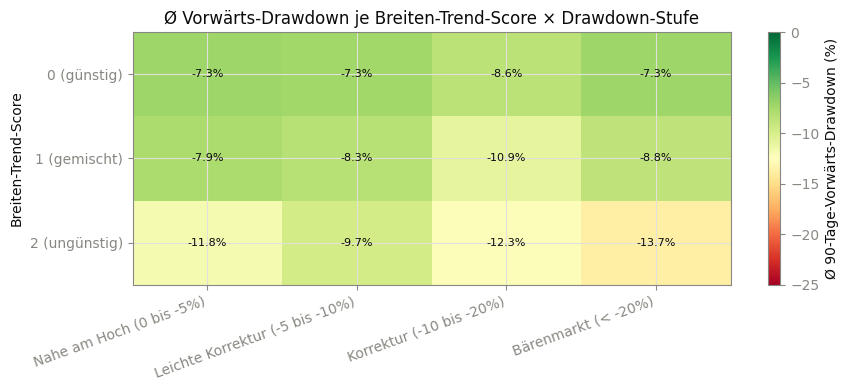

Drawdown_Bucket,Nahe am Hoch (0 bis -5%),Leichte Korrektur (-5 bis -10%),Korrektur (-10 bis -20%),Bärenmarkt (< -20%)
Breiten_Trend_Score,,,,
0.0000,-0.0730,-0.0733,-0.0858,-0.0726
1.0000,-0.0789,-0.0833,-0.1086,-0.0876
2.0000,-0.1182,-0.0969,-0.1226,-0.1370


In [30]:
heatmap_basis = df.groupby(["Breiten_Trend_Score", "Drawdown_Bucket"])["fwd_mdd_90d"].mean().unstack()
heatmap_basis = heatmap_basis[bucket_reihenfolge]

fig, achse = plt.subplots(figsize=(9, 4))
bild = achse.imshow(heatmap_basis.values * 100, cmap="RdYlGn", aspect="auto", vmin=-25, vmax=0)
achse.set_xticks(range(len(bucket_reihenfolge)))
achse.set_xticklabels(bucket_reihenfolge, rotation=20, ha="right")
achse.set_yticks(range(3))
achse.set_yticklabels(["0 (günstig)", "1 (gemischt)", "2 (ungünstig)"])
achse.set_ylabel("Breiten-Trend-Score")
for i in range(heatmap_basis.shape[0]):
    for j in range(heatmap_basis.shape[1]):
        wert = heatmap_basis.values[i, j]
        if not np.isnan(wert):
            achse.text(j, i, f"{wert * 100:.1f}%", ha="center", va="center", fontsize=8)
fig.colorbar(bild, ax=achse, label="Ø 90-Tage-Vorwärts-Drawdown (%)")
plt.title("Ø Vorwärts-Drawdown je Breiten-Trend-Score × Drawdown-Stufe")
plt.tight_layout()
plt.show()
heatmap_basis


### 6.3 Kategorienregel


In [31]:
def ampel_farbe(trend_score: float, drawdown_bucket: str) -> str:
    günstig = trend_score == 0
    ungünstig = trend_score == 2
    tief = drawdown_bucket in ("Korrektur (-10 bis -20%)", "Bärenmarkt (< -20%)")
    flach = drawdown_bucket in ("Nahe am Hoch (0 bis -5%)", "Leichte Korrektur (-5 bis -10%)")

    if günstig and flach:
        return "Grün"
    if ungünstig and tief:
        return "Rot"
    return "Gelb"


df["Ampel"] = [
    ampel_farbe(ts, db) if pd.notna(ts) else np.nan
    for ts, db in zip(df["Breiten_Trend_Score"], df["Drawdown_Bucket"])
]

print("Verteilung der Handelstage auf die drei Ampelfarben:")
print(df["Ampel"].value_counts().reindex(["Grün", "Gelb", "Rot"]))


Verteilung der Handelstage auf die drei Ampelfarben:


Ampel
Grün     892
Gelb    3403
Rot      520
Name: count, dtype: int64


### 6.4 Statistische Validierung der Ampelfarben


In [32]:
ampel_farben = ["Grün", "Gelb", "Rot"]
ampel_paare = [("Grün", "Gelb"), ("Gelb", "Rot"), ("Grün", "Rot")]

ergebnisse_ampel = []
for a, b in ampel_paare:
    maske_a = df["Ampel"] == a
    maske_b = df["Ampel"] == b
    for h in HORIZONS:
        for ziel in ["fwd_return", "fwd_mdd"]:
            res = vergleiche_gruppen(
                df.loc[maske_a, f"{ziel}_{h}d"], df.loc[maske_b, f"{ziel}_{h}d"],
                label_a=a, label_b=b,
            )
            if res:
                res.update({"vergleich": f"{a} vs. {b}", "horizont_tage": h, "zielgröße": ziel})
                ergebnisse_ampel.append(res)

tabelle_ampel = ergebnisse_zu_tabelle(ergebnisse_ampel)
tabelle_ampel[["vergleich", "horizont_tage", "zielgröße", "mean_a", "mean_b", "t_pvalue", "u_pvalue", "signifikant_5pct"]]


,vergleich,horizont_tage,zielgröße,mean_a,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,Grün vs. Gelb,30,fwd_return,0.0091,0.0088,0.8330,0.1552,False
1,Grün vs. Gelb,30,fwd_mdd,-0.0391,-0.0462,0.0000,0.0000,True
2,Grün vs. Gelb,60,fwd_return,0.0196,0.0185,0.6158,0.5691,False
3,Grün vs. Gelb,60,fwd_mdd,-0.0586,-0.0692,0.0000,0.0000,True
4,Grün vs. Gelb,90,fwd_return,0.0322,0.0283,0.1165,0.3417,False
5,Grün vs. Gelb,90,fwd_mdd,-0.0730,-0.0854,0.0000,0.0000,True
6,Gelb vs. Rot,30,fwd_return,0.0088,0.0210,0.0006,0.0000,True
7,Gelb vs. Rot,30,fwd_mdd,-0.0462,-0.0708,0.0000,0.0000,True
8,Gelb vs. Rot,60,fwd_return,0.0185,0.0285,0.0477,0.0000,True
9,Gelb vs. Rot,60,fwd_mdd,-0.0692,-0.1067,0.0000,0.0000,True


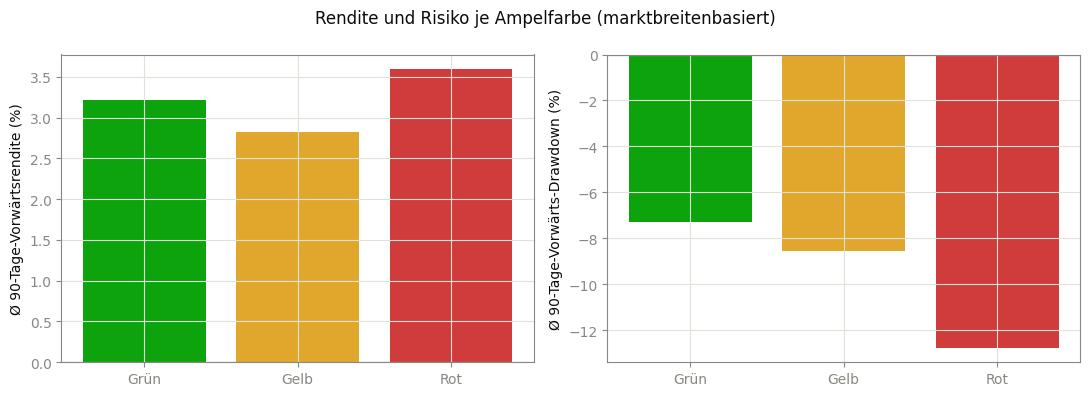

In [33]:
mittelwerte_ampel = df.groupby("Ampel")[["fwd_return_90d", "fwd_mdd_90d"]].mean().reindex(ampel_farben)
ampel_farbcodes = {"Grün": COLOR_GOOD, "Gelb": COLOR_WARN, "Rot": COLOR_BAD}

fig, achsen = plt.subplots(1, 2, figsize=(11, 4))
for achse, spalte, titel in zip(achsen, ["fwd_return_90d", "fwd_mdd_90d"],
                                 ["Ø 90-Tage-Vorwärtsrendite", "Ø 90-Tage-Vorwärts-Drawdown"]):
    achse.bar(mittelwerte_ampel.index, mittelwerte_ampel[spalte] * 100,
              color=[ampel_farbcodes[f] for f in mittelwerte_ampel.index])
    achse.axhline(0, color=COLOR_MUTED, linewidth=0.8)
    achse.set_ylabel(f"{titel} (%)")
fig.suptitle("Rendite und Risiko je Ampelfarbe (marktbreitenbasiert)")
fig.tight_layout()
plt.show()


**Ergebnis:** Verteilung der Handelstage: Grün 892 (18,5 %), Gelb 3.403
(70,7 %), Rot 520 (10,8 %). Das Risiko trennt alle drei Farbpaare in allen
drei Horizonten signifikant und monoton (mittlerer 90-Tage-Drawdown: Grün
-7,3 %, Gelb -8,5 %, Rot -12,8 %). Die Rendite ist deutlich weniger
trennscharf: Zwischen Grün und Gelb ist der Unterschied in keinem Horizont
signifikant. Zwischen Gelb und Rot ist die Rendite bei 30 und 60 Tagen
signifikant, zwischen Grün und Rot nur bei 30 Tagen - in allen
signifikanten Fällen liegt sie bei **Rot höher** als bei der jeweils
günstigeren Farbe (30 Tage: Grün 0,9 %, Gelb 0,9 %, Rot 2,1 %). Bei 90 Tagen
ist kein Farbpaar mehr signifikant, wobei Rot mit 3,6 % im Mittel weiterhin
etwas über Grün (3,2 %) und Gelb (2,8 %) liegt. Die marktbreitenbasierte
Ampel funktioniert damit klar als Risikostufung; bei der Rendite zeigt sich
- wie schon bei mehreren Einzelhypothesen - eher ein Mean-Reversion-Muster
als eine Bestätigung, dass Rot-Phasen auch renditeseitig ungünstiger wären.


### 6.5 Ampel-Hintergrund im Kursverlauf


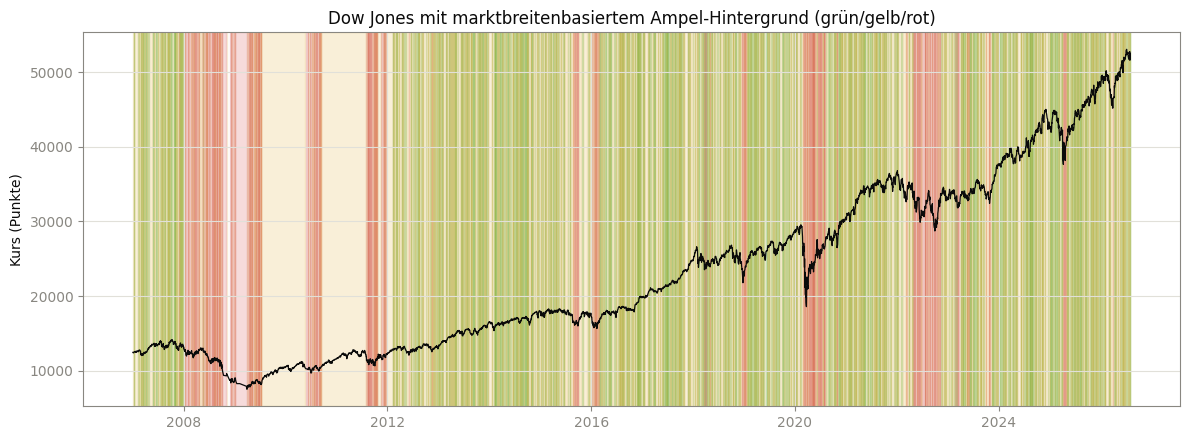

In [34]:
fig, achse = plt.subplots(figsize=(12, 4.5))
for farbe in ampel_farben:
    maske = df["Ampel"] == farbe
    achse.fill_between(df.index, 0, 1, where=maske, color=ampel_farbcodes[farbe], alpha=0.18,
                        transform=achse.get_xaxis_transform())
achse.plot(df.index, df["Close"], color=COLOR_PRICE, linewidth=0.9)
achse.set_ylabel("Kurs (Punkte)")
achse.set_title(f"{INDEX_NAME} mit marktbreitenbasiertem Ampel-Hintergrund (grün/gelb/rot)")
fig.tight_layout()
plt.show()


## 7. Was-wäre-wenn-Analyse: Wirkung des Risikophasen-Ausschlusses

Für jede Hypothese, bei der sich ein **anhaltender** Regimezustand
definieren lässt (im Unterschied zu den punktuellen Ereignishypothesen
B4-B9), wird simuliert, wie sich Gesamtrendite, annualisierte Rendite (CAGR)
und maximaler Drawdown verändert hätten, wenn an Tagen mit dem jeweils
ungünstigeren Regimezustand nicht investiert gewesen wäre.

**Methodische Abgrenzung:** Es wird ausschließlich der zum jeweiligen
Zeitpunkt bereits bekannte Regimezustand verwendet (kein Rückschaufehler).
Transaktionskosten und eine Verzinsung der Cash-Position an ausgeschlossenen
Tagen werden nicht berücksichtigt.

**B4, B5, B6, B7, B8 und B9 werden bewusst ausgeschlossen:** Es handelt sich
um seltene Punktereignisse bzw. Divergenzsignale ohne anhaltenden
Regimezustand - daraus lässt sich keine Phase ableiten, die über einen
längeren Zeitraum "ausgeschlossen" werden könnte. Einbezogen werden B1
(Marktbreite-Regime), B2 (Richtung der Marktbreite), B3 (unteres Quartil als
Risikostufe) sowie die kombinierte Ampel aus Abschnitt 6.


### 7.1 Backtest-Hilfsfunktionen


In [35]:
def historischer_max_drawdown(werte: pd.Series) -> float:
    laufendes_hoch = werte.cummax()
    return (werte / laufendes_hoch - 1).min()


def was_wäre_wenn(schlecht: pd.Series, label: str) -> dict:
    tagesrendite = df["Close"].pct_change().fillna(0)
    schlecht_bereinigt = schlecht.reindex(df.index).fillna(False)

    strategie_rendite = tagesrendite.where(~schlecht_bereinigt, 0)
    equity_buy_hold = (1 + tagesrendite).cumprod()
    equity_strategie = (1 + strategie_rendite).cumprod()

    jahre = (df.index[-1] - df.index[0]).days / 365.25

    def kennzahlen(equity: pd.Series) -> tuple[float, float, float]:
        gesamtrendite = equity.iloc[-1] - 1
        cagr = equity.iloc[-1] ** (1 / jahre) - 1
        mdd = historischer_max_drawdown(equity)
        return gesamtrendite, cagr, mdd

    gr_bh, cagr_bh, mdd_bh = kennzahlen(equity_buy_hold)
    gr_st, cagr_st, mdd_st = kennzahlen(equity_strategie)

    return {
        "hypothese": label,
        "anteil_schlecht_tage": schlecht_bereinigt.mean(),
        "gesamtrendite_buy_hold": gr_bh, "cagr_buy_hold": cagr_bh, "max_drawdown_buy_hold": mdd_bh,
        "gesamtrendite_strategie": gr_st, "cagr_strategie": cagr_st, "max_drawdown_strategie": mdd_st,
        "equity_buy_hold": equity_buy_hold, "equity_strategie": equity_strategie,
    }


print("Backtest-Hilfsfunktionen definiert.")


Backtest-Hilfsfunktionen definiert.


### 7.2 Regime-Definitionen je Hypothese


In [36]:
regime_definitionen: dict[str, pd.Series] = {}

for w in BREADTH_WINDOWS:
    über, _ = breite_regime(w)
    regime_definitionen[f"B1_SMA{w}"] = ~über.reindex(df.index).fillna(False)

for w in BREADTH_WINDOWS:
    steigend, _ = breite_richtung(w)
    regime_definitionen[f"B2_SMA{w}"] = ~steigend.reindex(df.index).fillna(False)

for w in BREADTH_WINDOWS:
    regime_definitionen[f"B3_SMA{w}_Q1"] = df[f"Quartil_SMA{w}"] == QUARTIL_LABELS[0]

regime_definitionen["Ampel_Rot"] = df["Ampel"] == "Rot"

# Um einen Rückschaufehler zu vermeiden, darf am Handelstag T nur der am
# Schlusskurs von T-1 bereits bekannte Regimezustand über die Teilnahme an
# Tag T entscheiden - nicht der auf Basis von T selbst berechnete Zustand.
regime_definitionen = {
    name: serie.reindex(df.index).fillna(False).shift(1).fillna(False).astype(bool)
    for name, serie in regime_definitionen.items()
}

print("Regime-Definitionen für die Was-wäre-wenn-Analyse:", list(regime_definitionen.keys()))


Regime-Definitionen für die Was-wäre-wenn-Analyse: ['B1_SMA20', 'B1_SMA50', 'B1_SMA200', 'B2_SMA20', 'B2_SMA50', 'B2_SMA200', 'B3_SMA20_Q1', 'B3_SMA50_Q1', 'B3_SMA200_Q1', 'Ampel_Rot']


### 7.3 Konsolidierte Kennzahlenübersicht


In [37]:
ergebnisse_www = [was_wäre_wenn(schlecht, name) for name, schlecht in regime_definitionen.items()]
tabelle_was_wäre_wenn = pd.DataFrame(ergebnisse_www).drop(columns=["equity_buy_hold", "equity_strategie"])
tabelle_was_wäre_wenn


,hypothese,anteil_schlecht_tage,gesamtrendite_buy_hold,cagr_buy_hold,max_drawdown_buy_hold,gesamtrendite_strategie,cagr_strategie,max_drawdown_strategie
0,B1_SMA20,0.3745,3.2074,0.0762,-0.4690,0.5485,0.0226,-0.4271
1,B1_SMA50,0.3410,3.2074,0.0762,-0.4690,0.1335,0.0064,-0.3620
2,B1_SMA200,0.2388,3.2074,0.0762,-0.4690,1.5042,0.0480,-0.2452
3,B2_SMA20,0.5809,3.2074,0.0762,-0.4690,-0.0149,-0.0008,-0.4928
4,B2_SMA50,0.6228,3.2074,0.0762,-0.4690,0.2842,0.0129,-0.4226
5,B2_SMA200,0.7144,3.2074,0.0762,-0.4690,-0.2840,-0.0169,-0.3755
6,B3_SMA20_Q1,0.1435,3.2074,0.0762,-0.4690,1.1153,0.0390,-0.4476
7,B3_SMA50_Q1,0.1047,3.2074,0.0762,-0.4690,1.4883,0.0477,-0.5164
8,B3_SMA200_Q1,0.0694,3.2074,0.0762,-0.4690,0.9184,0.0338,-0.4566
9,Ampel_Rot,0.1080,3.2074,0.0762,-0.4690,0.9241,0.0340,-0.4437


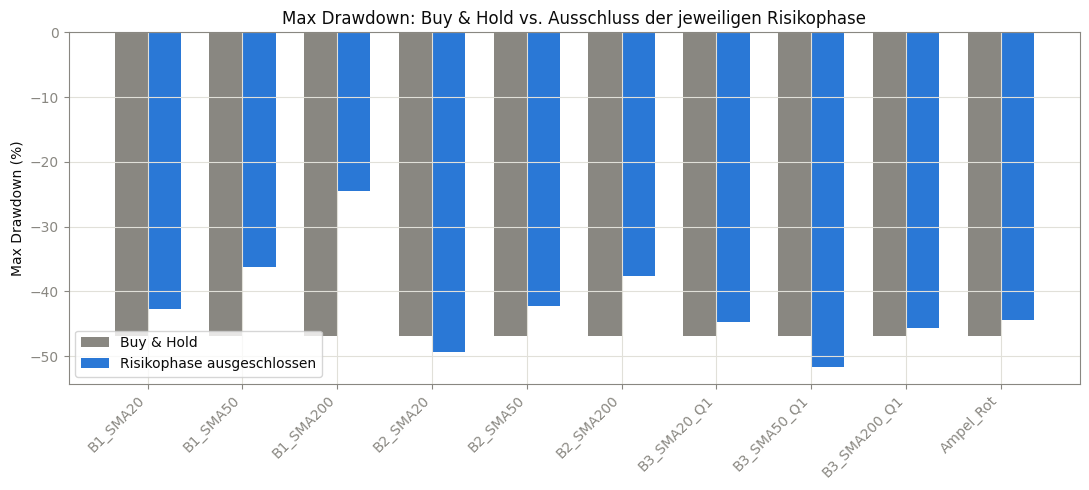

In [38]:
fig, achse = plt.subplots(figsize=(11, 5))
x = np.arange(len(tabelle_was_wäre_wenn))
breite = 0.35
achse.bar(x - breite / 2, tabelle_was_wäre_wenn["max_drawdown_buy_hold"] * 100, breite,
          label="Buy & Hold", color=COLOR_MUTED)
achse.bar(x + breite / 2, tabelle_was_wäre_wenn["max_drawdown_strategie"] * 100, breite,
          label="Risikophase ausgeschlossen", color=COLOR_A)
achse.set_xticks(x)
achse.set_xticklabels(tabelle_was_wäre_wenn["hypothese"], rotation=45, ha="right")
achse.set_ylabel("Max Drawdown (%)")
achse.legend()
plt.title("Max Drawdown: Buy & Hold vs. Ausschluss der jeweiligen Risikophase")
plt.tight_layout()
plt.show()


**Ergebnis:** Buy & Hold erzielt seit 2007 eine Gesamtrendite von 321 %
(CAGR 7,6 %) bei einem Max Drawdown von -46,9 %. Der Ausschluss der
jeweils „schlechten“ Marktbreite-Regime senkt den Max Drawdown nicht in
allen zehn Parametrisierungen: Am stärksten wirkt B1/SMA200 (23,9 %
ausgeschlossene Tage), das den Max Drawdown auf -24,5 % senkt, bei einer
gegenüber Buy & Hold moderat geringeren CAGR von 4,8 %. Die kombinierte
Ampel (10,8 % ausgeschlossene Tage, Max Drawdown -44,4 %, CAGR 3,4 %) und
B3/SMA200_Q1 (6,9 % ausgeschlossene Tage, Max Drawdown -45,7 %, CAGR
3,4 %) reduzieren das Risiko dagegen nur noch geringfügig gegenüber Buy &
Hold. Bei B2 (Richtung der Marktbreite, 58-71 % ausgeschlossene Tage je
Fenster) und bei B3/SMA50_Q1 verbessert sich der Max Drawdown teils gar
nicht oder verschlechtert sich sogar (B2/SMA20: -49,3 %; B3/SMA50_Q1:
-51,6 % gegenüber -46,9 % bei Buy & Hold), bei durchgehend negativer oder
allenfalls neutraler CAGR.


### 7.4 Vertiefte Einzelbetrachtung

Für die kombinierte Ampel (Rot-Phasen) wird zusätzlich der zeitliche
Verlauf dargestellt: oben der Kursverlauf mit rot hinterlegter
Ausschlussphase, darunter die Wertentwicklung von Buy & Hold gegenüber der
Ausschluss-Strategie (logarithmische Skala, Startwert = 1).


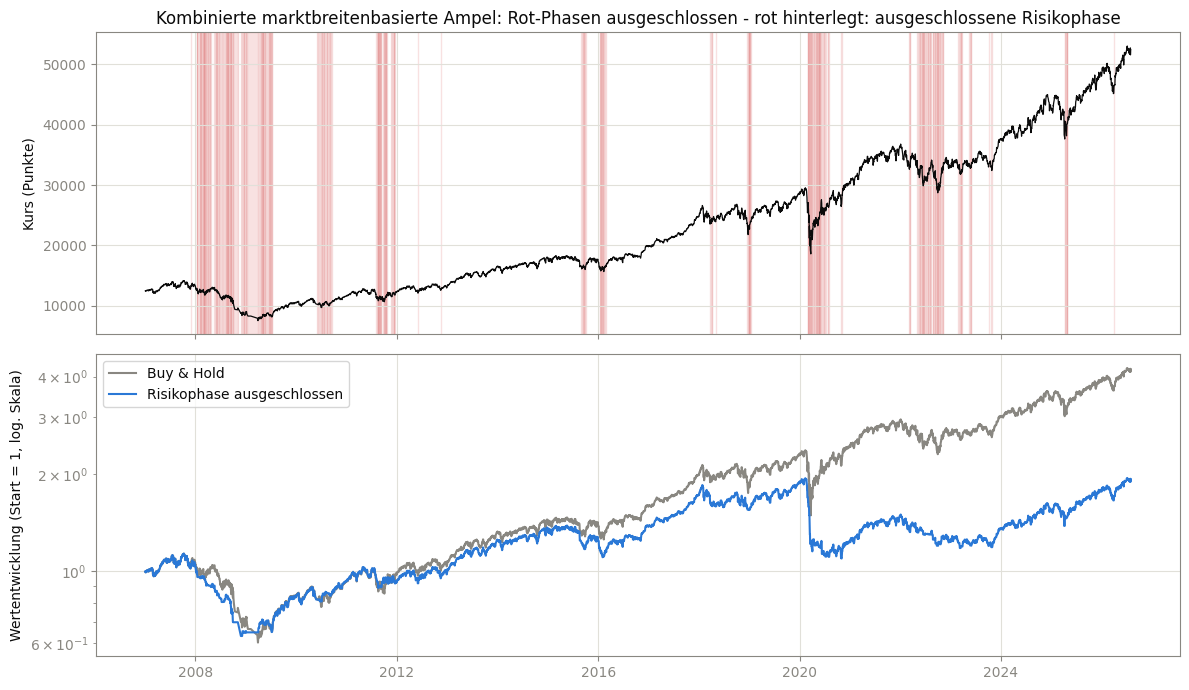

Anteil ausgeschlossener Handelstage: 10.8%
Gesamtrendite  - Buy & Hold: 320.7% | Ausschluss: 92.4%
CAGR           - Buy & Hold: 7.6% | Ausschluss: 3.4%
Max Drawdown   - Buy & Hold: -46.9% | Ausschluss: -44.4%


In [39]:
def plotte_was_wäre_wenn(name: str, schlecht: pd.Series, titel: str) -> dict:
    ergebnis = was_wäre_wenn(schlecht, name)
    schlecht_reindiziert = schlecht.reindex(df.index).fillna(False)

    fig, (achse_kurs, achse_equity) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    achse_kurs.fill_between(df.index, 0, 1, where=schlecht_reindiziert, color=COLOR_BAD, alpha=0.15,
                             transform=achse_kurs.get_xaxis_transform())
    achse_kurs.plot(df.index, df["Close"], color=COLOR_PRICE, linewidth=0.9)
    achse_kurs.set_ylabel("Kurs (Punkte)")
    achse_kurs.set_title(f"{titel} - rot hinterlegt: ausgeschlossene Risikophase")

    achse_equity.plot(df.index, ergebnis["equity_buy_hold"], color=COLOR_MUTED, label="Buy & Hold")
    achse_equity.plot(df.index, ergebnis["equity_strategie"], color=COLOR_A, label="Risikophase ausgeschlossen")
    achse_equity.set_yscale("log")
    achse_equity.set_ylabel("Wertentwicklung (Start = 1, log. Skala)")
    achse_equity.legend()

    fig.tight_layout()
    plt.show()

    print(f"Anteil ausgeschlossener Handelstage: {ergebnis['anteil_schlecht_tage']:.1%}")
    print(f"Gesamtrendite  - Buy & Hold: {ergebnis['gesamtrendite_buy_hold']:.1%} | Ausschluss: {ergebnis['gesamtrendite_strategie']:.1%}")
    print(f"CAGR           - Buy & Hold: {ergebnis['cagr_buy_hold']:.1%} | Ausschluss: {ergebnis['cagr_strategie']:.1%}")
    print(f"Max Drawdown   - Buy & Hold: {ergebnis['max_drawdown_buy_hold']:.1%} | Ausschluss: {ergebnis['max_drawdown_strategie']:.1%}")
    return ergebnis


_ = plotte_was_wäre_wenn("Ampel_Rot", regime_definitionen["Ampel_Rot"], "Kombinierte marktbreitenbasierte Ampel: Rot-Phasen ausgeschlossen")


**Ergebnis:** Der Ausschluss der 10,8 % Rot-Handelstage senkt den Max
Drawdown von -46,9 % (Buy & Hold) nur geringfügig auf -44,4 % und senkt
zugleich die annualisierte Rendite deutlich von 7,6 % auf 3,4 %. Der
Risikophasen-Ausschluss ist damit auch beim Dow Jones kein „Free Lunch“:
Die Ampel reduziert das Tail-Risiko kaum, kostet aber gut die Hälfte der
jährlichen Rendite. Der Kursverlauf zeigt, dass die Rot-Phasen
erwartungsgemäß mit den großen historischen Krisenphasen (2008/2009,
2020, 2022) zusammenfallen.


## 8. Export der Ergebnisse


In [40]:
INDEX_DATEINAME = INDEX_NAME.replace(" ", "_").replace("&", "and")

xlsx_pfad = EXPORT_DIR / f"{INDEX_DATEINAME}_Marktbreite_hypothesenanalysen.xlsx"
with pd.ExcelWriter(xlsx_pfad, engine="openpyxl") as writer:
    for name, tabelle in alle_ergebnisse.items():
        if tabelle is not None and len(tabelle) > 0:
            tabelle.to_excel(writer, sheet_name=name[:31], index=False)
    tabelle_robustheit.to_excel(writer, sheet_name="Robustheit_Übersicht", index=False)
    tabelle_ampel.to_excel(writer, sheet_name="Ampel_Validierung", index=False)
    tabelle_was_wäre_wenn.to_excel(writer, sheet_name="Was_wäre_wenn", index=False)

csv_dateien = []
for name, tabelle in alle_ergebnisse.items():
    if tabelle is None or len(tabelle) == 0:
        continue
    csv_pfad = EXPORT_DIR / f"{INDEX_DATEINAME}_{name}.csv"
    tabelle.to_csv(csv_pfad, index=False)
    csv_dateien.append(csv_pfad.name)

robustheit_csv = EXPORT_DIR / f"{INDEX_DATEINAME}_Robustheit_Übersicht.csv"
tabelle_robustheit.to_csv(robustheit_csv, index=False)
csv_dateien.append(robustheit_csv.name)

ampel_csv = EXPORT_DIR / f"{INDEX_DATEINAME}_Ampel_Validierung.csv"
tabelle_ampel.to_csv(ampel_csv, index=False)
csv_dateien.append(ampel_csv.name)

was_wäre_wenn_csv = EXPORT_DIR / f"{INDEX_DATEINAME}_Was_wäre_wenn.csv"
tabelle_was_wäre_wenn.to_csv(was_wäre_wenn_csv, index=False)
csv_dateien.append(was_wäre_wenn_csv.name)

print(f"Excel-Arbeitsmappe gespeichert: {xlsx_pfad}")
print("Einzel-CSV-Dateien gespeichert:")
for f in csv_dateien:
    print(" -", f)


Excel-Arbeitsmappe gespeichert: Hypothesenanalysen\Dow_Jones_Marktbreite_hypothesenanalysen.xlsx
Einzel-CSV-Dateien gespeichert:
 - Dow_Jones_B1_Breite_Regime.csv
 - Dow_Jones_B2_Breite_Richtung.csv
 - Dow_Jones_B3_Breite_Quartile.csv
 - Dow_Jones_B4_Frühindikator_Krise.csv
 - Dow_Jones_B5_Frühindikator_Erholung.csv
 - Dow_Jones_B6_Wochentrend_positiv_Breiteneinbruch.csv
 - Dow_Jones_B7_Wochentrend_negativ_Breitenstabilisierung.csv
 - Dow_Jones_B8_Divergenz_Kurshoch_Breite.csv
 - Dow_Jones_B9_Breadth_Thrust_Collapse.csv
 - Dow_Jones_Robustheit_Übersicht.csv
 - Dow_Jones_Ampel_Validierung.csv
 - Dow_Jones_Was_wäre_wenn.csv


## 9. Zusammenfassung


Dieses Notebook untersucht, ob die Marktbreite des Dow Jones (Anteil der
Indexmitglieder über ihrem eigenen SMA20/50/200) eine eigenständige,
statistisch prüfbare Aussagekraft für die Rendite- und Risikoentwicklung
des Gesamtindex besitzt. Datengrundlage sind tägliche TradingView-
Breitendaten (2007-2026) sowie bereits bereinigte Kurs- und SMA-Daten des
Index.

**Kernbefunde:**

- Das *Niveau* der Marktbreite (B1: Regime > 50 %/< 50 %; B3: Quartile)
  liefert die robustesten Signale: Risiko durchgehend signifikant (18/18
  Kombinationen), Rendite teilweise (B1: 6/9) bis vollständig (B3: 9/9)
  signifikant.
- Die *Richtung* der Marktbreite (B2) liefert dagegen kaum eigenständige
  Information (2 von 18 signifikant, beide bei SMA200).
- Die sequenziellen Frühindikator-Hypothesen (B4-B7) zeigen überwiegend
  entweder keinen oder einen dem Hypothesentext **entgegengesetzten**
  Effekt: B4 ist größtenteils neutral (nur der 90-Tage-Drawdown signifikant,
  dort **geringeres** statt höheres Risiko); B6 zeigt nur bei SMA20 ein
  signifikantes, ebenfalls entgegengesetztes Risikosignal; B5 und B7
  (Signale bei negativem Wochentrend) gehen dagegen konsistent mit
  **höherem** Risiko einher statt einer "ruhigen Erholung".
- B8 (Divergenz Kurshoch/Breite) durchbricht dieses Muster teilweise: Für
  SMA200 bestätigt sich auf dem 30-Tage-Horizont tatsächlich die klassische
  Warnung vor einer "nicht bestätigten Rally" (niedrigere Rendite, höheres
  Risiko bei unbestätigten Hochs); bei SMA20/SMA50 sowie bei längeren
  Horizonten zeigt sich dagegen kein signifikanter Unterschied.
- B9 zeigt das differenzierteste Bild: Breadth Collapse geht robust mit
  **höherer** Rendite einher (Mean-Reversion), bei SMA50/SMA200 zusätzlich
  mit kurzfristig **höherem** Risiko. Der SMA200-Breadth-Thrust sticht
  dagegen als einziges Ereignissignal im gesamten Notebook mit einem
  durchgehend **bestätigten** Kaufsignal hervor: höhere Rendite in allen
  drei Horizonten, bei 60/90 Tagen zusätzlich signifikant **niedrigeres**
  Risiko.
- Die marktbreitenbasierte Ampel (Kapitel 6) trennt das Risiko klar und
  monoton (Grün -7,3 %, Gelb -8,5 %, Rot -12,8 % mittlerer 90-Tage-
  Drawdown), die Rendite deutlich weniger; wo signifikant, liegt sie in
  Rot-Phasen sogar höher als in Grün/Gelb (Mean-Reversion). Der Ausschluss
  der Rot-Phasen (10,8 % der Handelstage) senkt den historischen Max
  Drawdown nur geringfügig von -46,9 % auf -44,4 %, bei einem deutlichen
  Rückgang der CAGR von 7,6 % auf 3,4 % (Kapitel 7).

**Übergreifende Einordnung:** Technische Signale auf Basis der Marktbreite
taugen überwiegend zuverlässiger als Risikoindikator denn als
Renditeprognose. Für punktuelle Schwellenkreuzungen zeigt sich mehrheitlich
eine Mean-Reversion-Tendenz statt einer Bestätigung der jeweils formulierten
Warnhypothese - mit dem SMA200-Breadth-Thrust (B9) und der kurzfristigen
SMA200-Divergenz (B8) als bemerkenswerten Ausnahmen, die tatsächlich in die
ursprünglich erwartete Richtung wirken.
